# 1. Setup

## 1.1 Imports

In [1]:
import pandas as pd
import numpy as np

import warnings
from enum import Enum

from scipy import stats

from pathlib import Path

import matplotlib.pyplot as plt

from numpy.linalg import lstsq
from scipy.stats import kruskal
import scikit_posthocs as sp
import statsmodels.formula.api as smf
import seaborn as sns

## 1.2. Paths

In [2]:
input_path = Path("data/input/06_input")
output_path = Path("data/output/06_output")

## 1.3 Store TXT files as CSV

In [3]:
for file_path in input_path.iterdir():
    # Skip directories, hidden/system files (e.g. .DS_Store), and any
    # non-data files. Adjust the suffix set to match your raw extensions.
    if not file_path.is_file():
        continue
    if file_path.name.startswith("."):
        continue
    if file_path.suffix.lower() not in {".txt", ".csv"}:
        continue

    file = pd.read_csv(file_path, sep="|")
    file.to_csv(file_path.with_suffix(".csv"), sep="|", index=False)

# 2. Clinical outcome definition & reduction

In [4]:
# Read file
all_clinical_06 = pd.read_csv(input_path / "AllClinical06.csv", sep="|")

## 2.1 Aggregate x-ray dataset for KL grade

In [5]:
"""
V06XRKL defines Kellgren and Lawrence grade from 0-4
0 = none (definite absence of x-ray changes of osteoarthritis)
1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)
2 = minimal (definite osteophytes and possible joint space narrowing)
3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)
4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)
"""

xr_df = pd.read_csv(input_path / "KXR_SQ_BU06.csv", sep="|")

# select Kellgren and Lawrence Score and take max grade per ID and side
xr_df_grade = xr_df[["ID", "SIDE", "V06XRKL"]]
xr_df_grade = xr_df_grade.groupby(["ID", "SIDE"])["V06XRKL"].max().reset_index()

# clean label format from SIDE and V06XRKL (e.g. "1: Right" --> "Right", "2: 2" -> "2")
xr_df_grade["SIDE"] = xr_df_grade["SIDE"].str.extract(r":\s*(\w+)")
xr_df_grade["V06XRKL"] = xr_df_grade["V06XRKL"].str.extract(r":\s*(\d+)").squeeze().astype(float).astype("Int64")

# Pivot from long to wide format -> one row per ID, separate columns for Left and Right
xr_df_wide = xr_df_grade.pivot(index="ID", columns="SIDE", values="V06XRKL")
xr_df_wide.columns = [f"V06XRKL_{col}" for col in xr_df_wide.columns]
xr_df_wide = xr_df_wide.reset_index()

print(xr_df_wide)

           ID  V06XRKL_Left  V06XRKL_Right
0     9000099             4              2
1     9000296             3              2
2     9000798             4              1
3     9001695             0              3
4     9001897             1              3
...       ...           ...            ...
3659  9999295             0              2
3660  9999365             0              0
3661  9999510             3              1
3662  9999865             1              0
3663  9999878             1              2

[3664 rows x 3 columns]


### Merge x-ray with clinical dataset

In [6]:
all_clinical_06_merged = xr_df_wide.merge(all_clinical_06, on="ID", how="inner")

## 2.2 Missing-data exploration

In [7]:
print("Missing columns:")
for col in all_clinical_06:
    missing = all_clinical_06[col].isna().sum()
    print(f"{col}: {missing}/{len(all_clinical_06[col])}")

Missing columns:
ID: 0/4796
VERSION: 0/4796
V06BLDRAW2: 4779/4796
V06ILLPWK2: 4778/4796
V06MULTST2: 4783/4796
V06URINOB1: 978/4796
V06PLAQHR1: 1037/4796
V06BLUPMN2: 4784/4796
V06HOURSP2: 4785/4796
V06VCOLL2: 4783/4796
V06ILLPWK1: 992/4796
V06MULTST1: 1004/4796
V06VEIN2: 4783/4796
V06URUPMN2: 4787/4796
V06VCOLL1: 1005/4796
V06HOURSP1: 1022/4796
V06HRSUC1: 1020/4796
V06URNCOLL: 540/4796
V06EXCESS2: 4783/4796
V06BLDRAW1: 996/4796
V06URINHR1: 1004/4796
V06HRSUC2: 4787/4796
V06QOVP1: 1005/4796
V06EXCESS1: 1005/4796
V06BLDCOLL: 540/4796
V06SEAQHR1: 1023/4796
V06VOID1: 550/4796
V06QOVP2: 4783/4796
V06VEIN1: 1004/4796
V06OTHVP1: 1004/4796
V06SEAQHR2: 4785/4796
V06OTHVP2: 4783/4796
V06URINHR2: 4787/4796
V06HEMAT1: 1005/4796
V06LEAKAG2: 4783/4796
V06BLSURD1: 4003/4796
V06BLDHRS1: 1021/4796
V06URSURD1: 3995/4796
V06URUPMN1: 1012/4796
V06HEMAT2: 4783/4796
V06LEAKAG1: 1005/4796
V06BLSURD2: 4793/4796
V06VOID2: 4659/4796
V06PLAQHR2: 4785/4796
V06URINOB2: 4665/4796
V06BLDHRS2: 4784/4796
V06URSURD2: 47

## 2.3 Domain candidate variable groups

Candidates are identified into 6 domains:
- pain
- function
- depression
- self-reported function and symptoms
- participation
- quality of life

In [8]:
pain_cols = [
        "V06KOOSKPR",   # Right knee: KOOS Pain Score, 0-100
        "V06WOMKPR",    # Right knee: WOMAC Pain Score, 0-20
        "V06CPSKR",     # ICOAP Right knee: Constant Pain Score, 0-100
        "V06IPSKR",     # ICOAP Right knee: Intermittent Pain Score, 0-100
        "V06ICPTSKR",   # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
        "V06P7RKACV",   # Right knee pain: on average, past 7 days, rated on scale of 0-10
        "V06P7RKRCV",   # Right knee pain: severity, past 7 days, rated on scale of 0-10

        "V06KOOSKPL",   # Left knee: KOOS Pain Score
        "V06WOMKPL",    # Left knee: WOMAC Pain Score
        "V06CPSKL",     # ICOAP Left knee: Constant Pain Score
        "V06IPSKL",     # ICOAP Left knee: Intermittent Pain Score
        "V06ICPTSKL",   # ICOAP Left knee: Intermittent and Constant Pain Total Score
        "V06P7LKACV",   # Left knee pain: on average, past 7 days, rated on scale of 0-10
        "V06P7LKRCV",   # Left knee pain: severity, past 7 days, rated on scale of 0-10
    ]

function_cols = [
        "V0620MPACE",   # 20-meter walk: pace (m/sec)
        "V06STEPST1",   # 20-meter walk: trial 1 number of steps
        "V06STEPST2",   # 20-meter walk: trial 2 number of steps
        "V06TIMET1",    # 20-meter walk: trial 1 time to complete (sec.hundredths/sec)
        "V06TIMET2",    # 20-meter walk: trial 2 time to complete (sec.hundredths/sec)
        "V06WLK20T1",   # 20-meter walk: trial 1 result
        "V06WLK20T2",   # 20-meter walk: trial 2 result
        "V06WLKAID",    # 20-meter walk: using walking aid such as cane

        "V06400EXCL",   # 400-meter walk: reason excluded
        "V06400MCMP",   # 400-meter walk: completion status
        "V06400MTIM",   # 400-meter walk: total time at 400-m or at stop (sec)
        "V06400MTR",    # 400-meter walk: total meters walked
        "V06400PAIN",   # 400-meter walk: knee pain, which leg
        "V06CANEUSE",   # 400-meter walk: use cane
        "V06COMP10",    # 400-meter walk: complete full 10 laps
        "V06DISCOMF",   # 400-meter walk: any discomfort
        "V06DKP400W",   # 400-meter walk: knee pain during walk, don't know
        "V06HR135",     # 400-meter walk: heart rate exceed 135 bpm during walk
        "V06HR400WK",   # 400-meter walk: heart rate at 400-m or at stop
        "V06HRB4WLK",   # 400-meter walk: heart rate before walk
        "V06LPN400W",   # 400-meter walk: left knee pain during walk
        "V06LPWKPRV",   # 400-meter walk: left knee pain prevent walking at usual pace
        "V06LPWKTYP",   # 400-meter walk: left knee pain mild, moderate or severe
        "V06NPN400W",   # 400-meter walk: no knee pain during walk
        "V06NUMSTOP",   # 400-meter walk: total number rest stops
        "V06OTH400W",   # 400-meter walk: type of discomfort, other
        "V06PN400W",    # 400-meter walk: type of discomfort, pain
        "V06REASW1",    # 400-meter walk: not able to complete 10 laps
        "V06REASW2",    # 400-meter walk: not able to complete 10 laps, began walk but could not complete
        "V06REASW3",    # 400-meter walk: not able to complete 10 laps, heart rate exceeded 135 bpm during walk and did not feel                 well
        "V06REASW4",    # 400-meter walk: not able to complete 10 laps, heart rate fell below 40 bpm during walk
        "V06REASW5",    # 400-meter walk: not able to complete 10 laps, reported felt too tired during walk
        "V06REASW6",    # 400-meter walk: not able to complete 10 laps, reported chest pain during walk
        "V06REASW7",    # 400-meter walk: not able to complete 10 laps, reported shortness of breath during walk
        "V06REASW8",    # 400-meter walk: not able to complete 10 laps, reported feeling faint during walk
        "V06REASW9",    # 400-meter walk: not able to complete 10 laps, reported knee pain during walk
        "V06REASW10",   # 400-meter walk: not able to complete 10 laps, reported hip pain during walk
        "V06REASW11",   # 400-meter walk: not able to complete 10 laps, reported calf pain during walk
        "V06REASW12",   # 400-meter walk: not able to complete 10 laps, reported back pain during walk
        "V06REASW13",   # 400-meter walk: not able to complete 10 laps, sat down during walk
        "V06REASW14",   # 400-meter walk: not able to complete 10 laps, more than 15 minutes elapsed from start of test
        "V06REASW15",   # 400-meter walk: not able to complete 10 laps, refused
        "V06REASW16",   # 400-meter walk: not able to complete 10 laps, other
        "V06RESTT1",    # 400-meter walk: rest stop #1
        "V06RESTT2",    # 400-meter walk: rest stop #2
        "V06RESTT3",    # 400-meter walk: rest stop #3
        "V06RESTT4",    # 400-meter walk: rest stop #4
        "V06RESTT5",    # 400-meter walk: rest stop #5
        "V06RESTT6",    # 400-meter walk: rest stop #6
        "V06RESTT7",    # 400-meter walk: rest stop #7
        "V06RESTT8",    # 400-meter walk: rest stop #8
        "V06RESTT9",    # 400-meter walk: rest stop #9
        "V06RESTT10",   #400-meter walk: rest stop #10
        "V06RFP400W",   # 400-meter walk: knee pain during walk, refused
        "V06RPN400W",   # 400-meter walk: right knee pain during walk
        "V06RPWKPRV",   # 400-meter walk: right knee pain prevent from walking at usual pace
        "V06RPWKTYP",   # 400-meter walk: right knee pain mild, moderate or severe
        "V06SOB400W",   # 400-meter walk: type of discomfort, shortness of breath
        "V06SAFEWLK",   # 400-meter walk eligibility: feel it would be safe to try to walk up and down hallway
        "V06SYSELG",    # 400-meter walk eligibility: meets new or old systolic blood pressure exclusion criterion
        "V06W20COMP",   # 400-meter walk eligibility: able to complete trial 1 and trial 2 of the 20-meter walk
        "V06WALKER",    # 400-meter walk eligibility: use walker or quad cane when walk
        "V06WHE400W",   # 400-meter walk: type of discomfort, wheezing/dyspnea
        "V06CALLDOC",   # 400-meter walk eligibility: had to see or call doctor for worsening angina (chest or heart pain) or                    worsening shortness of breath, past 3 months
        "V06DIASELG",   # 400-meter walk eligibility: meets new or old diastolic blood pressure exclusion criterion
        "V06HOSPSUR",   # 400-meter walk eligibility: meets new or old hospitalization/surgery exclusion criteria
        "V06HRELG",     # 400-meter walk eligibility: meets old or new heart rate exclusion criterion

        "V06CSTSGL",    # Single chair stand
        "V06CSTREP1",   # Repeated chair stands: trial 1
        "V06CSTIME1",   # Repeated chair stands: trial 1 time (sec.hundredths/sec) 12
        "V06CSTNUM1",   # Repeated chair stands: trial 1, attempted, unable to complete: number completed without using arms
        "V06CSTIME2",   # Repeated chair stands: trial 2 time (sec.hundredths/sec)
        "V06CSTNUM2",   # Repeated chair stands: trial 2, attempted, unable to complete: number completed without using arms
        "V06CSTREP2",   # Repeated chair stands: trial 2
        "V06CS5",       # Repeated chair stands: able to complete 5 stands
        "V06CSPACE",    # Repeated chair stand: pace in stands/sec
    ]

depression_cols = [
        "V06CESD",      # CES-D: Center for Epidemiologic Studies Depression Scale (CES-D) Score
    ]

self_reported_function_symptoms_cols = [
        # KOOS / WOMAC / Function
        "V06WOMADLR",   # Right knee: WOMAC Disability Score
        "V06WOMADLL",   # Left knee: WOMAC Disability Score
        "V06KOOSFSR",    # KOOS Function, Sports, and Recreational Activities Score
        "V06KOOSYML",   # Left knee: KOOS symptoms Score
        "V06KOOSYMR",   # Right knee: KOOS symptoms Score
    ]

participation_cols = [
        # Late Life Disability (LLD)
        "V06LLDIFST",   # LLDI: Late Life Disability Instrument, Frequency Dimension, Total Score
        "V06LLDILST",   # LLDI: Late Life Disability Instrument, Limitation Dimension, Total Score
        "V06LLDIFSS",   # LLDI: Late Life Disability Instrument, Frequency Dimension, Social Role Domain Score
        "V06LLDIFSP",   # LLDI: Late Life Disability Instrument, Frequency Dimension, Personal Role Domain Score
        "V06LLDILSI",   # LLDI: Late Life Disability Instrument, Limitation Dimension, Instrumental Role Domain Score
        "V06LLDILSM",   # LLDI: Late Life Disability Instrument, Limitation Dimension, Management Role Domain Score
]

quality_of_life_cols = [
        "V06KOOSQOL",    # KOOS Quality of Life Score
    ]

## 2.4 Redundancy reduction

### 2.4.1 Redundancy functions (Spearman matrix, redundant-pair report)

In [9]:
def compute_spearman_correlation_matrix(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """
    Compute a pairwise Spearman correlation matrix for the given columns.

    Missing values are handled pairwise. Columns with fewer than 10
    joint observations are set to NaN. Constant input pairs are silently
    set to NaN rather than raising a ConstantInputWarning.

    :param dataframe: DataFrame containing the columns.
    :param columns: List of column names to include.
    :returns: Symmetric DataFrame of Spearman correlation coefficients.
    """
    import warnings
    from scipy.stats import ConstantInputWarning

    valid_columns = [
        column for column in columns
        if column in dataframe.columns
        and pd.api.types.is_numeric_dtype(dataframe[column])
        and dataframe[column].nunique() > 1
    ]

    number_of_columns = len(valid_columns)
    correlation_matrix = pd.DataFrame(
        data=np.eye(number_of_columns),
        index=valid_columns,
        columns=valid_columns,
    )

    for index_i, column_i in enumerate(valid_columns):
        for index_j in range(index_i + 1, number_of_columns):
            column_j = valid_columns[index_j]
            joint_observations = dataframe[[column_i, column_j]].dropna()

            if len(joint_observations) < 10:
                correlation_matrix.loc[column_i, column_j] = np.nan
                correlation_matrix.loc[column_j, column_i] = np.nan
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                rho, _ = stats.spearmanr(
                    joint_observations[column_i],
                    joint_observations[column_j],
                )

            if np.isnan(rho):
                correlation_matrix.loc[column_i, column_j] = np.nan
                correlation_matrix.loc[column_j, column_i] = np.nan
            else:
                correlation_matrix.loc[column_i, column_j] = rho
                correlation_matrix.loc[column_j, column_i] = rho

    return correlation_matrix

def print_redundant_pairs(
    correlation_matrix: pd.DataFrame,
    redundancy_threshold: float = 0.85,
) -> pd.DataFrame:
    """
    Print and return all variable pairs exceeding the redundancy threshold.

    :param correlation_matrix: Pairwise Spearman correlation matrix.
    :param redundancy_threshold: Absolute correlation above which two
        variables are considered redundant. Defaults to 0.85.
    :returns: DataFrame of redundant pairs sorted by correlation strength,
        or an empty DataFrame if no redundant pairs are found.
    """
    variables = list(correlation_matrix.columns)
    redundant_pairs = []

    for index_i, variable_i in enumerate(variables):
        for index_j in range(index_i + 1, len(variables)):
            variable_j = variables[index_j]
            rho = correlation_matrix.loc[variable_i, variable_j]

            if pd.isna(rho):
                continue

            if abs(rho) >= redundancy_threshold:
                redundant_pairs.append({
                    "variable_a": variable_i,
                    "variable_b": variable_j,
                    "spearman_rho": round(rho, 3),
                })

    print(f"\nRedundant pairs (|ρ| ≥ {redundancy_threshold})")
    print(f"{'Variable A':<20} {'Variable B':<20} {'ρ':>6}")
    print("-" * 50)

    # --- early return BEFORE attempting sort ---
    if not redundant_pairs:
        print("No redundant pairs found — all variables are sufficiently distinct.")
        return pd.DataFrame(columns=["variable_a", "variable_b", "spearman_rho"])

    pairs_dataframe = (
        pd.DataFrame(redundant_pairs)
        .sort_values(by="spearman_rho", key=lambda column: column.abs(), ascending=False)
        .reset_index(drop=True)
    )

    for _, row in pairs_dataframe.iterrows():
        print(
            f"{row['variable_a']:<20} "
            f"{row['variable_b']:<20} "
            f"{row['spearman_rho']:>6.3f}"
        )
    print(f"\n{len(pairs_dataframe)} redundant pairs found.")

    return pairs_dataframe

### 2.4.2 Per-domain redundancy assessment

In [10]:
domain_candidate_columns = dict(
    pain=pain_cols,
    function=function_cols,
    self_reported=self_reported_function_symptoms_cols,
    participation=participation_cols,
)

redundancy_reports = {
    domain_name: print_redundant_pairs(
        correlation_matrix=compute_spearman_correlation_matrix(
            dataframe=all_clinical_06_merged,
            columns=columns,
        ),
        redundancy_threshold=0.85,
    )
    for domain_name, columns in domain_candidate_columns.items()
}


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06KOOSKPR           V06WOMKPR            -0.938
V06KOOSKPL           V06WOMKPL            -0.930
V06IPSKR             V06ICPTSKR            0.924
V06IPSKL             V06ICPTSKL            0.918
V06KOOSKPL           V06P7LKRCV           -0.905
V06P7LKACV           V06P7LKRCV            0.894
V06KOOSKPR           V06P7RKRCV           -0.893
V06P7RKACV           V06P7RKRCV            0.884
V06WOMKPR            V06P7RKRCV            0.863
V06WOMKPL            V06P7LKRCV            0.860
V06ICPTSKL           V06P7LKRCV            0.860

11 redundant pairs found.

Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06WLK20T2           V06W20COMP           -1.000
V06400MTR            V06COMP10             1.000
V06400MCMP           V06COMP10            -0.994
V06CSTIME2           V06CSP

### 2.4.3 Reduced outcome variabels + rationale

Redundant variables were identified using pairwise Spearman correlations
(|ρ| ≥ 0.85) within each domain group. Manual selection was applied based
on three criteria:

1. **Redundancy result** — one representative retained per redundant cluster
2. **Instrument hierarchy (applies to both stages)** —  Within a construct, validated composites are preferred over their constituents or single items (KOOS over WOMAC; ICOAP total over the constant subscale; CES-D total over items). This is pre-specified, not learned from the data.
3. **Clinical relevance** — more interpretable and widely used measures
   preferred (e.g. pace in m/s over raw trial times)

In [11]:
REDUCED_OUTCOME_VARIABLES = {
    "pain_right": [
        "V06KOOSKPR",  # KOOS Pain right knee — preferred over WOMAC (contains WOMAC, 0-100 scale)
        "V06CPSKR",    # ICOAP Constant Pain right knee — distinct from KOOS (ρ < 0.85)
        "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
    ],
    "pain_left": [
        "V06KOOSKPL",  # KOOS Pain left knee
        "V06CPSKL",   # ICOAP Constant Pain left knee
        "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score
    ],
    "function": [
        "V0620MPACE",  # 20m walk pace (m/s) — represents full 20m walk cluster
        "V06STEPST1",  # 20-meter walk: trial 1 number of steps
        "V06WLKAID",   # 20-meter walk: using walking aid such as cane

        "V06400MTIM",   # 400-meter walk: total time at 400-m or at stop (sec)
        "V06400MTR",    # 400-meter walk: total meters walked
        "V06400PAIN",   # 400-meter walk: knee pain, which leg
        "V06CANEUSE",   # 400-meter walk: use cane
        "V06DISCOMF",   # 400-meter walk: any discomfort
        "V06DKP400W",   # 400-meter walk: knee pain during walk, don't know
        "V06HR135",     # 400-meter walk: heart rate exceed 135 bpm during walk
        "V06HR400WK",   # 400-meter walk: heart rate at 400-m or at stop
        "V06HRB4WLK",   # 400-meter walk: heart rate before walk
        "V06LPN400W",   # 400-meter walk: left knee pain during walk
        "V06LPWKPRV",   # 400-meter walk: left knee pain prevent walking at usual pace
        "V06LPWKTYP",   # 400-meter walk: left knee pain mild, moderate or severe
        "V06NPN400W",   # 400-meter walk: no knee pain during walk
        "V06NUMSTOP",   # 400-meter walk: total number rest stops
        "V06OTH400W",   # 400-meter walk: type of discomfort, other
        "V06PN400W",    # 400-meter walk: type of discomfort, pain
        "V06REASW1",    # 400-meter walk: not able to complete 10 laps
        "V06REASW2",    # 400-meter walk: not able to complete 10 laps, began walk but could not complete
        "V06REASW3",    # 400-meter walk: not able to complete 10 laps, heart rate exceeded 135 bpm during walk and did not feel                 well
        "V06REASW4",    # 400-meter walk: not able to complete 10 laps, heart rate fell below 40 bpm during walk
        "V06REASW5",    # 400-meter walk: not able to complete 10 laps, reported felt too tired during walk
        "V06REASW6",    # 400-meter walk: not able to complete 10 laps, reported chest pain during walk
        "V06REASW7",    # 400-meter walk: not able to complete 10 laps, reported shortness of breath during walk
        "V06REASW8",    # 400-meter walk: not able to complete 10 laps, reported feeling faint during walk
        "V06REASW9",    # 400-meter walk: not able to complete 10 laps, reported knee pain during walk
        "V06REASW10",   # 400-meter walk: not able to complete 10 laps, reported hip pain during walk
        "V06REASW11",   # 400-meter walk: not able to complete 10 laps, reported calf pain during walk
        "V06REASW12",   # 400-meter walk: not able to complete 10 laps, reported back pain during walk
        "V06REASW13",   # 400-meter walk: not able to complete 10 laps, sat down during walk
        "V06REASW14",   # 400-meter walk: not able to complete 10 laps, more than 15 minutes elapsed from start of test
        "V06REASW15",   # 400-meter walk: not able to complete 10 laps, refused
        "V06REASW16",   # 400-meter walk: not able to complete 10 laps, other
        "V06RESTT1",    # 400-meter walk: rest stop #1
        "V06RESTT2",    # 400-meter walk: rest stop #2
        "V06RESTT3",    # 400-meter walk: rest stop #3
        "V06RESTT4",    # 400-meter walk: rest stop #4
        "V06RESTT5",    # 400-meter walk: rest stop #5
        "V06RESTT6",    # 400-meter walk: rest stop #6
        "V06RESTT7",    # 400-meter walk: rest stop #7
        "V06RESTT8",    # 400-meter walk: rest stop #8
        "V06RESTT9",    # 400-meter walk: rest stop #9
        "V06RESTT10",   #400-meter walk: rest stop #10
        "V06RFP400W",   # 400-meter walk: knee pain during walk, refused
        "V06RPN400W",   # 400-meter walk: right knee pain during walk
        "V06RPWKPRV",   # 400-meter walk: right knee pain prevent from walking at usual pace
        "V06RPWKTYP",   # 400-meter walk: right knee pain mild, moderate or severe
        "V06SOB400W",   # 400-meter walk: type of discomfort, shortness of breath
        "V06SAFEWLK",   # 400-meter walk eligibility: feel it would be safe to try to walk up and down hallway
        "V06SYSELG",    # 400-meter walk eligibility: meets new or old systolic blood pressure exclusion criterion
        "V06W20COMP",   # 400-meter walk eligibility: able to complete trial 1 and trial 2 of the 20-meter walk
        "V06WALKER",    # 400-meter walk eligibility: use walker or quad cane when walk
        "V06WHE400W",   # 400-meter walk: type of discomfort, wheezing/dyspnea
        "V06CALLDOC",   # 400-meter walk eligibility: had to see or call doctor for worsening angina (chest or heart pain) or                    worsening shortness of breath, past 3 months
        "V06DIASELG",   # 400-meter walk eligibility: meets new or old diastolic blood pressure exclusion criterion
        "V06HOSPSUR",   # 400-meter walk eligibility: meets new or old hospitalization/surgery exclusion criteria
        "V06HRELG",     # 400-meter walk eligibility: meets old or new heart rate exclusion criterion


        "V06CSTSGL",   # Single chair stand
        "V06CSTREP1",  # Repeated chair stands: trial 1
        "V06CSTREP2",  # Repeated chair stands: trial 2
        "V06CSTNUM1",   # Repeated chair stands: trial 1, attempted, unable to complete: number completed without using arms
        "V06CSTNUM2",   # Repeated chair stands: trial 2, attempted, unable to complete: number completed without using arms
        "V06CSTIME1",  # Repeated chair stands: trial 1 time (sec.hundredths/sec)
    ],
     "depression": [
        "V06CESD",      # CES-D: Center for Epidemiologic Studies Depression Scale (CES-D) Score
    ],

    "self_reported_function_symptoms_right": [
        "V06WOMADLR", # Right knee: WOMAC Disability Score
        "V06KOOSYMR",   # Right knee: KOOS symptoms Score
        ],
    "self_reported_function_symptoms_left": [
        "V06WOMADLL", # Left knee: WOMAC Disability Score
        "V06KOOSYML",   # Left knee: KOOS symptoms Score
    ],
    "self_reported_function_bilateral": [
        "V06KOOSFSR",  # KOOS Function in Sport and Recreation subscale score
    ],

    "participation":[
       # Late Life Disability (LLD)
        "V06LLDIFST",   # LLDI: Late Life Disability Instrument, Frequency Dimension, Total Score
        "V06LLDILST",   # LLDI: Late Life Disability Instrument, Limitation Dimension, Total Score
        "V06LLDIFSP",   # LLDI: Late Life Disability Instrument, Frequency Dimension, Personal Role Domain Score
        "V06LLDILSM",   # LLDI: Late Life Disability Instrument, Limitation Dimension, Management Role Domain Score
    ],

    "quality_of_life":[
        "V06KOOSQOL",    # KOOS Quality of Life Score
    ],
}

In [12]:
all_clinical_06_merged.to_csv(output_path / "all_clinical_06_merged.csv", sep="|", index=False)

In [13]:
print("Missing values per outcome variable:")
total_rows = len(all_clinical_06_merged)
for domain_name, column_names in REDUCED_OUTCOME_VARIABLES.items():
    print(f"\n{domain_name}:")
    for column_name in column_names:
        missing_count = all_clinical_06_merged[column_name].isna().sum()
        missing_share = missing_count / total_rows
        print(f"  {column_name}: {missing_count}/{total_rows} ({missing_share:.1%})")

Missing values per outcome variable:

pain_right:
  V06KOOSKPR: 4/3664 (0.1%)
  V06CPSKR: 60/3664 (1.6%)
  V06ICPTSKR: 64/3664 (1.7%)

pain_left:
  V06KOOSKPL: 4/3664 (0.1%)
  V06CPSKL: 60/3664 (1.6%)
  V06ICPTSKL: 65/3664 (1.8%)

function:
  V0620MPACE: 122/3664 (3.3%)
  V06STEPST1: 122/3664 (3.3%)
  V06WLKAID: 121/3664 (3.3%)
  V06400MTIM: 565/3664 (15.4%)
  V06400MTR: 561/3664 (15.3%)
  V06400PAIN: 563/3664 (15.4%)
  V06CANEUSE: 560/3664 (15.3%)
  V06DISCOMF: 558/3664 (15.2%)
  V06DKP400W: 3664/3664 (100.0%)
  V06HR135: 563/3664 (15.4%)
  V06HR400WK: 568/3664 (15.5%)
  V06HRB4WLK: 530/3664 (14.5%)
  V06LPN400W: 3171/3664 (86.5%)
  V06LPWKPRV: 3173/3664 (86.6%)
  V06LPWKTYP: 3172/3664 (86.6%)
  V06NPN400W: 1380/3664 (37.7%)
  V06NUMSTOP: 562/3664 (15.3%)
  V06OTH400W: 3374/3664 (92.1%)
  V06PN400W: 3300/3664 (90.1%)
  V06REASW1: 3337/3664 (91.1%)
  V06REASW2: 3629/3664 (99.0%)
  V06REASW3: 3662/3664 (99.9%)
  V06REASW4: 3664/3664 (100.0%)
  V06REASW5: 3650/3664 (99.6%)
  V06REASW6: 3

## 2.5 Reduced outcome variable specification (V06, exploratory development sample)

Selection operates at the *construct* level, not via a further empirical
 filter (pairwise Spearman redundancy is already resolved upstream):
   1. Within-construct multiplicity is resolved by an a-priori measurement
      hierarchy (validated composite before constituent or single item),
     pre-specified rather than learned from data. E.g. the ICOAP total is
   kept over its constant-pain subscale, of which it is a constituent.
   2. Parameters that are not knee-function outcomes (cardiovascular response,
      assistive-device use, procedural counts, raw components summarised
      elsewhere) are excluded on construct grounds, not by filtering.
   3. Laterality is retained: left and right measures are kept separate,
      consistent with the pipeline. Left/right variants of one instrument
      share a multiplicity-correction family (Stage 8) to avoid counting a
      single construct twice.
   4. Beyond redundancy, a variable was excluded when its missingness exceeded
      **20% of the sample**. Like the redundancy cutoff (|ρ| ≥ 0.85), this threshold is pre-specified.

In [14]:
final_outcome_variables = [
    # ----------------------------------------------------------------------
    # RETAINED (16)
    # ----------------------------------------------------------------------

    # pain
    "V06KOOSKPR",  # KOOS Pain right knee (WOMAC-based composite, 0-100)
    "V06ICPTSKR",  # ICOAP total pain right knee (constant + intermittent)
    "V06KOOSKPL",  # KOOS Pain left knee (WOMAC-based composite, 0-100)
    "V06ICPTSKL",  # ICOAP total pain left knee (constant + intermittent)

    # function
    "V0620MPACE",  # 20-metre walk pace (m/s): gait speed
    "V06CSTIME1",  # Repeated chair stands: trial 1 time (sec)
    "V06400MTIM",  # 400-metre walk total time (exploratory)
    "V06400MTR",   # 400-metre walk total metres walked (exploratory)

    # self-reported function and symptoms
    "V06WOMADLR",  # Right knee WOMAC Disability (task-level self-reported function)
    "V06KOOSYMR",  # Right knee KOOS Symptoms (distinct from pain and function)
    "V06WOMADLL",  # Left knee WOMAC Disability (task-level self-reported function)
    "V06KOOSYML",  # Left knee KOOS Symptoms (distinct from pain and function)

    # depression
    "V06CESD",     # CES-D total score

    # participation
    "V06LLDILST",  # LLDI Limitation dimension total (perceived participation restriction)
    "V06LLDIFST",  # LLDI Frequency dimension total (frequency of participation)

    # quality of life
    "V06KOOSQOL",  # KOOS Quality of Life score

    # ----------------------------------------------------------------------
    # DROPPED (66) — retained through Stage 1, excluded at Stage 2 (construct level)
    # ----------------------------------------------------------------------
    #
    # -- Pain: constituent of a retained composite --
    #   V06CPSKR, V06CPSKL           — ICOAP constant subscale, constituent of the ICOAP total
    #
    # -- Function: summarised by a retained measure --
    #   V06STEPST1                   — 20 m step count: no established MDC, captured by gait speed
    #   V06CSTSGL                    — single chair stand: summarised by V06CSTIME1
    #   V06CSTREP1, V06CSTREP2       — chair-stand trial counts: summarised by V06CSTIME1
    #   V06CSTNUM1, V06CSTNUM2       — partial-completion stand counts: summarised by V06CSTIME1
    #
    # -- Function: not a knee-function outcome (cardiovascular) --
    #   V06HR135, V06HR400WK, V06HRB4WLK
    #
    # -- Function: not a knee-function outcome (assistive-device use) --
    #   V06WLKAID, V06CANEUSE, V06WALKER
    #
    # -- Function: not a knee-function outcome (procedural) --
    #   V06NUMSTOP                   — total number of rest stops
    #   V06RESTT1 ... V06RESTT10     — rest-stop timings
    #   V06REASW1 ... V06REASW16     — reasons the 10-lap walk was not completed
    #
    # -- Function: symptom-during-test items (not an outcome measure) --
    #   V06400PAIN, V06DISCOMF, V06DKP400W, V06NPN400W, V06PN400W, V06OTH400W,
    #   V06SOB400W, V06WHE400W,
    #   V06LPN400W, V06LPWKPRV, V06LPWKTYP,
    #   V06RPN400W, V06RPWKPRV, V06RPWKTYP, V06RFP400W
    #
    # -- Function: eligibility items (not an outcome) --
    #   V06SAFEWLK, V06SYSELG, V06DIASELG, V06HRELG, V06HOSPSUR,
    #   V06CALLDOC, V06WALKER, V06W20COMP
    #
    # -- Self-reported: missingness above the 20% threshold --
    #   V06KOOSFSR                   — KOOS Function in Sport and Recreation subscale
    #
    # -- Participation: constituent of a retained total --
    #   V06LLDIFSP                   — Frequency Personal-Role subdomain, part of the Frequency total
    #   V06LLDILSM                   — Limitation Management-Role subdomain, part of the Limitation total
]

In [15]:
print("Missing values per outcome variable:")
total_rows = len(all_clinical_06_merged)
for column_name in final_outcome_variables:
    missing_count = all_clinical_06_merged[column_name].isna().sum()
    missing_share = missing_count / total_rows
    print(f"  {column_name}: {missing_count}/{total_rows} ({missing_share:.1%})")

Missing values per outcome variable:
  V06KOOSKPR: 4/3664 (0.1%)
  V06ICPTSKR: 64/3664 (1.7%)
  V06KOOSKPL: 4/3664 (0.1%)
  V06ICPTSKL: 65/3664 (1.8%)
  V0620MPACE: 122/3664 (3.3%)
  V06CSTIME1: 293/3664 (8.0%)
  V06400MTIM: 565/3664 (15.4%)
  V06400MTR: 561/3664 (15.3%)
  V06WOMADLR: 13/3664 (0.4%)
  V06KOOSYMR: 4/3664 (0.1%)
  V06WOMADLL: 17/3664 (0.5%)
  V06KOOSYML: 3/3664 (0.1%)
  V06CESD: 41/3664 (1.1%)
  V06LLDILST: 487/3664 (13.3%)
  V06LLDIFST: 427/3664 (11.7%)
  V06KOOSQOL: 4/3664 (0.1%)


# 3. Build cohort dataframes

## 3.1. Subject summary metrics (accelerometry + clinical + KL + sex)

In [16]:
# drop non-participants from the Accelerometry data for valid ID's
Accelerometry06 = pd.read_csv(input_path / "Accelerometry06.csv", sep="|")

accelerometry_valid_participants_06 = Accelerometry06[Accelerometry06["V06APASTAT"] != "Not participating"]

In [17]:
# create summary_metrics_06 dataframe with relevant columns from accelerometry_valid_participants_06, all_clinical_06, and x-ray dataset (KL grade) and enrollees dataset

summary_metrics_06 = pd.DataFrame()

"""
Decision to use Trioano cut points for activity intensity classification, as these were validated in a population with rheumatic diseases and are commonly used in OAI accelerometer research. Freedson was validated on young healthy adults and underestimates MVPA in older populations, while Swartz overestimates it. The cut points are based on counts per minute (cpm) thresholds that correspond to different activity intensities:
light: 100-2019 cpm
moderate: 2020-5998 cpm
vigorous: >= 5999 cpm
"""

activity_cols = [
    "ID",
    "V06AACNT", # average daily counts
    "V06AALTMNT", # average daily light activity counts Trioano
    "V06AAMDMNT", # average daily moderate activity counts Trioano
    "V06AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V06AAVMNT", # average daily vigorous activity counts Trioano
    "V06ANVDAYS", # number of valid days (exposed downstream as valid_days_oai)
]

summary_metrics_06 = accelerometry_valid_participants_06[activity_cols].rename(
    columns={"V06ANVDAYS": "valid_days_oai"}
)

In [18]:
print(f"Invited Participants: {Accelerometry06['ID'].nunique()}")
print(f"Accelerometer participants: {accelerometry_valid_participants_06['ID'].nunique()}")
print(f"After merge: {summary_metrics_06['ID'].nunique()}")
print(f"Did not participate: {(Accelerometry06['ID'].nunique()) - (accelerometry_valid_participants_06['ID'].nunique()) }")

Invited Participants: 2712
Accelerometer participants: 2127
After merge: 2127
Did not participate: 585


In [19]:
# merge outcome variables from all_clinical_06_merged
all_clinical_cols = [
    # basic parameter"ID",
    "ID", "V06AGE", "V06WEIGHT", "V06HEIGHT", "V06BMI", "V06COMORB", "V06CEMPLOY",
]
summary_metrics_06 = summary_metrics_06.merge(all_clinical_06_merged[all_clinical_cols], on="ID", how="left")
summary_metrics_06 = summary_metrics_06.merge(
    right=all_clinical_06_merged[["ID"] + final_outcome_variables],
    on="ID",
    how="left",
)

In [20]:
print(summary_metrics_06.columns)

Index(['ID', 'V06AACNT', 'V06AALTMNT', 'V06AAMDMNT', 'V06AAMVMNT', 'V06AAVMNT',
       'valid_days_oai', 'V06AGE', 'V06WEIGHT', 'V06HEIGHT', 'V06BMI',
       'V06COMORB', 'V06CEMPLOY', 'V06KOOSKPR', 'V06ICPTSKR', 'V06KOOSKPL',
       'V06ICPTSKL', 'V0620MPACE', 'V06CSTIME1', 'V06400MTIM', 'V06400MTR',
       'V06WOMADLR', 'V06KOOSYMR', 'V06WOMADLL', 'V06KOOSYML', 'V06CESD',
       'V06LLDILST', 'V06LLDIFST', 'V06KOOSQOL'],
      dtype='str')


### Aggregate Enrollees for SEX column

In [21]:
enrollees_df = pd.read_csv(input_path / "Enrollees.csv", sep="|")

#clean label format from P02SEX (e.g. "1: Male" --> "Male")
enrollees_df["P02SEX"] = enrollees_df["P02SEX"].str.extract(r":\s*(\w+)")


### Merge summary_metrics_06 with x-ray (KL grade) and enrollees (sex)

In [22]:
summary_metrics_06 = (summary_metrics_06
                      .merge(xr_df_wide, on="ID", how="inner")
                      .merge(enrollees_df[["ID", "P02SEX"]], on="ID", how="inner")
                      )

# Verify — any drop beyond accelerometer filtering is a data quality signal
accelerometer_participant_count = accelerometry_valid_participants_06["ID"].nunique()
final_participant_count = summary_metrics_06["ID"].nunique()

# include KL grade per patient for later use in stratification and subgroup analyses; use worse knee (max of left and right) as KL grade per patient
kl_grade_per_patient = (
    xr_df_wide[["ID", "V06XRKL_Left", "V06XRKL_Right"]]
    .copy()
)
kl_grade_per_patient["kl_grade_index_knee"] = kl_grade_per_patient[
    ["V06XRKL_Left", "V06XRKL_Right"]
].max(axis=1)

# Merge KL grade into summary data
summary_metrics_06 = summary_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

print(f"Valid accelerometer participants: {accelerometer_participant_count}")
print(f"Final participants after all merges: {final_participant_count}")
print(f"Dropped by downstream merges: {accelerometer_participant_count - final_participant_count}")


Valid accelerometer participants: 2127
Final participants after all merges: 2056
Dropped by downstream merges: 71


In [23]:
accel_ids = set(accelerometry_valid_participants_06["ID"])
xr_ids = set(xr_df_wide["ID"])
enr_ids = set(enrollees_df["ID"])

print("Missing from X-ray frame:", len(accel_ids - xr_ids))
print("Missing from enrollees:", len(accel_ids - enr_ids))
print("Missing from either:", len(accel_ids - (xr_ids & enr_ids)))

Missing from X-ray frame: 71
Missing from enrollees: 0
Missing from either: 71


In [24]:
print(
    "Survivors with no usable KL grade:",
    summary_metrics_06["kl_grade_index_knee"].isna().sum(),
)

Survivors with no usable KL grade: 1


In [25]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
print(summary_metrics_06.shape)

(2056, 33)


In [26]:
mask = summary_metrics_06["kl_grade_index_knee"].isna()
print(summary_metrics_06.loc[mask, ["ID", "V06XRKL_Left", "V06XRKL_Right"]])

           ID  V06XRKL_Left  V06XRKL_Right
1537  9742871          <NA>           <NA>


In [27]:
before = summary_metrics_06["ID"].nunique()

summary_metrics_06 = summary_metrics_06[
    summary_metrics_06["kl_grade_index_knee"].notna()
].copy()

after = summary_metrics_06["ID"].nunique()
print(f"Dropped for unusable KL grade: {before - after}")  # expect 1
print(f"Final participants: {after}")  # expect 2055

Dropped for unusable KL grade: 1
Final participants: 2055


## 3.2 Drop participants with prior knee surgery

### read relevant follow up visits

at baseline and at the yearly follow up visits the participants get questioned if they had surgery the last 12 months

In [28]:
clinical_frames_by_visit = {
"baseline" : pd.read_csv(input_path / "AllClinical00.csv", sep="|"),
"v01" : pd.read_csv(input_path / "AllClinical01.csv", sep="|"),
"v03" : pd.read_csv(input_path / "AllClinical03.csv", sep="|"),
"v05" : pd.read_csv(input_path / "AllClinical05.csv", sep="|"),
"v06": pd.read_csv(input_path / "AllClinical06.csv", sep="|"),
}

In [29]:
ID_COLUMN: str = "ID"
YES_CODE: int = 1  # confirmed encoding: 1 = Yes (surgery), 0 = No

# Each visit's right/left "surgery or arthroscopy" variables. Baseline (P01)
# asks "ever"; each follow-up asks "since last visit ~12 months". The union
# across visits gives cumulative surgery history up to V06.
SURGERY_ITEMS_BY_VISIT: dict[str, tuple[str, str]] = {
    # visit_code: (right_knee_variable, left_knee_variable)
    "baseline": ("P01KSURGR", "P01KSURGL"),   # "ever had surgery or arthroscopy"
    "v01": ("V01KSRGR12", "V01KSRGL12"),       # "since last visit ~12 months"
    "v03": ("V03KSRGR12", "V03KSRGL12"),
    "v05": ("V05KSRGR12", "V05KSRGL12"),
    "v06": ("V06KSRGR12", "V06KSRGL12"),
}

In [30]:
def parse_surgery_code(raw_series: pd.Series) -> pd.Series:
    """Parse an OAI surgery item into a numeric code (0 = No, 1 = Yes).

    Handles both labelled values such as ``"1: Yes"`` and bare values such as
    ``1`` or ``"0"``. Any value whose leading token is not a digit (for example
    ``".: Missing Form/Incomplete Workbook"``) becomes missing.

    :param raw_series: Surgery item as read from the clinical file.
    :returns: Numeric series with missing values for non-coded entries.
    """
    leading_token = raw_series.astype(str).str.strip().str.split(":").str[0]
    return pd.to_numeric(leading_token, errors="coerce")

def merge_surgery_columns(
    clinical_frames_by_visit: dict[str, pd.DataFrame],
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    id_column: str = ID_COLUMN,
) -> pd.DataFrame:
    """Merge the right/left surgery columns from every visit onto one frame.

    Only the identifier and the two surgery variables are taken from each
    visit, then merged on the identifier with an outer join so that no
    participant is dropped for being absent at a given visit. Surgery codes are
    coerced to numeric, turning blanks and stray codes into missing values.

    :param clinical_frames_by_visit: Mapping from visit label to its loaded
        data frame. Must contain every visit named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param id_column: Name of the participant identifier column.
    :returns: One row per participant, indexed by identifier, containing the
        surgery columns from all visits as numeric values.
    """
    merged_surgery_data: pd.DataFrame | None = None

    for visit_label, surgery_columns in surgery_items_by_visit.items():
        if visit_label not in clinical_frames_by_visit:
            raise KeyError(f"No data frame supplied for visit '{visit_label}'.")

        clinical_frame = clinical_frames_by_visit[visit_label]
        right_column, left_column = surgery_columns

        missing_columns = {id_column, right_column, left_column} - set(clinical_frame.columns)
        if missing_columns:
            raise KeyError(
                f"Visit '{visit_label}' is missing expected column(s): "
                f"{sorted(missing_columns)}"
            )

        visit_subset = clinical_frame[[id_column, right_column, left_column]].copy()
        visit_subset[[right_column, left_column]] = visit_subset[
            [right_column, left_column]
        ].apply(parse_surgery_code)

        if merged_surgery_data is None:
            merged_surgery_data = visit_subset
        else:
            merged_surgery_data = merged_surgery_data.merge(
                visit_subset, on=id_column, how="outer"
            )

    return merged_surgery_data.set_index(id_column)


def build_prior_knee_surgery_exclusion(
    merged_clinical_data: pd.DataFrame,
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    yes_code: int = YES_CODE,
    treat_missing_as_surgery: bool = False,
) -> pd.Series:
    """Flag participants reporting any knee surgery across the included visits.

    A participant is flagged when any right- or left-knee surgery item, at any
    visit, equals ``yes_code``. Because the source encoding is 0 = No, 1 = Yes
    with "don't know" stored as missing, the missing-value policy is set
    explicitly rather than via a numeric code.

    :param merged_clinical_data: One row per participant, indexed by identifier,
        containing the surgery columns named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param yes_code: Encoded value representing an affirmative response.
    :param treat_missing_as_surgery: When ``True``, a participant whose every
        surgery item is missing is also flagged, for a conservative exclusion.
        When ``False`` (default), only explicit affirmative responses flag.
    :returns: Boolean series indexed by identifier, ``True`` where the
        participant should be excluded.
    """
    surgery_columns = [
        column
        for right_left_pair in surgery_items_by_visit.values()
        for column in right_left_pair
    ]

    affirmative = merged_clinical_data[surgery_columns].eq(yes_code)
    exclude = affirmative.any(axis="columns")

    if treat_missing_as_surgery:
        all_missing = merged_clinical_data[surgery_columns].isna().all(axis="columns")
        exclude |= all_missing

    return exclude


def summarize_surgery_by_visit(
    merged_clinical_data: pd.DataFrame,
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    yes_code: int = YES_CODE,
) -> pd.DataFrame:
    """Count participants reporting knee surgery at each visit.

    For every visit, a participant counts as reporting surgery when either the
    right- or left-knee item equals ``yes_code``. Because baseline asks "ever"
    and follow-ups ask "since last visit", these counts are not mutually
    exclusive across visits and should not be summed into a total.

    :param merged_clinical_data: One row per participant, indexed by identifier,
        containing the surgery columns named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param yes_code: Encoded value representing an affirmative response.
    :returns: Data frame indexed by visit label, with the number reporting
        surgery, the number explicitly answering, and the number missing.
    """
    summary_rows: dict[str, dict[str, int]] = {}

    for visit_label, (right_column, left_column) in surgery_items_by_visit.items():
        visit_codes = merged_clinical_data[[right_column, left_column]]
        reported_surgery = visit_codes.eq(yes_code).any(axis="columns")
        answered = visit_codes.notna().any(axis="columns")

        summary_rows[visit_label] = {
            "reported_surgery": int(reported_surgery.sum()),
            "answered": int(answered.sum()),
            "missing_all": int((~answered).sum()),
        }

    return pd.DataFrame.from_dict(summary_rows, orient="index")



In [31]:
merged_surgery_data = merge_surgery_columns(clinical_frames_by_visit)

# Sanity check: baseline 'answered' should be ~4788 and v01 ~4471, not 0.
surgery_by_visit = summarize_surgery_by_visit(merged_surgery_data)
print(surgery_by_visit)

surgery_exclusion_mask = build_prior_knee_surgery_exclusion(merged_surgery_data)
surgery_participant_ids = set(merged_surgery_data.index[surgery_exclusion_mask])

summary_metrics_06_filtered = summary_metrics_06.loc[
    ~summary_metrics_06[ID_COLUMN].isin(surgery_participant_ids)
].copy()

print(f"Participants flagged for knee surgery: {len(surgery_participant_ids)}")
print(f"Summary rows before: {len(summary_metrics_06)}")
print(f"Summary rows after:  {len(summary_metrics_06_filtered)}")

          reported_surgery  answered  missing_all
baseline              1084      4790            6
v01                    114      4473          323
v03                     90      4309          487
v05                    134      4258          538
v06                    141      4238          558
Participants flagged for knee surgery: 1322
Summary rows before: 2055
Summary rows after:  1492


In [32]:
def summarize_surgery_by_visit(
    merged_clinical_data: pd.DataFrame,
    *,
    surgery_items_by_visit: dict[str, tuple[str, str]] = SURGERY_ITEMS_BY_VISIT,
    yes_code: int = YES_CODE,
) -> pd.DataFrame:
    """Count participants reporting knee surgery at each visit.

    For every visit, a participant counts as reporting surgery when either the
    right- or left-knee item equals ``yes_code``. Because baseline asks "ever"
    and follow-ups ask "since last visit", these counts are not mutually
    exclusive across visits and should not be summed into a total.

    :param merged_clinical_data: One row per participant, indexed by identifier,
        containing the surgery columns named in ``surgery_items_by_visit``.
    :param surgery_items_by_visit: Mapping from visit label to the right- and
        left-knee surgery variable names for that visit.
    :param yes_code: Encoded value representing an affirmative response.
    :returns: Data frame indexed by visit label, with the number reporting
        surgery, the number explicitly answering, and the number missing.
    """
    summary_rows: dict[str, dict[str, int]] = {}

    for visit_label, (right_column, left_column) in surgery_items_by_visit.items():
        visit_codes = merged_clinical_data[[right_column, left_column]]
        reported_surgery = visit_codes.eq(yes_code).any(axis="columns")
        answered = visit_codes.notna().any(axis="columns")

        summary_rows[visit_label] = {
            "reported_surgery": int(reported_surgery.sum()),
            "answered": int(answered.sum()),
            "missing_all": int((~answered).sum()),
        }

    return pd.DataFrame.from_dict(summary_rows, orient="index")

In [33]:
surgery_by_visit = summarize_surgery_by_visit(merged_surgery_data)
print(surgery_by_visit)

          reported_surgery  answered  missing_all
baseline              1084      4790            6
v01                    114      4473          323
v03                     90      4309          487
v05                    134      4258          538
v06                    141      4238          558


In [34]:
# --- Exclude participants with any reported knee surgery (baseline → V06) ----

surgery_exclusion_mask = build_prior_knee_surgery_exclusion(merged_surgery_data)
surgery_participant_ids = set(merged_surgery_data.index[surgery_exclusion_mask])

# Guard: confirm IDs actually align before trusting the row count. A dtype or
# format mismatch makes .isin match nothing and silently drop zero rows.
summary_ids = set(summary_metrics_06["ID"])
overlap = surgery_participant_ids & summary_ids
print(f"Flagged for surgery (all visits): {len(surgery_participant_ids)}")
print(f"Of those, present in final summary cohort: {len(overlap)}")
assert overlap, "No flagged IDs matched summary_metrics_06 — check ID dtype/format."

before_surgery = summary_metrics_06["ID"].nunique()
summary_metrics_06 = summary_metrics_06[
    ~summary_metrics_06["ID"].isin(surgery_participant_ids)
].copy()
after_surgery = summary_metrics_06["ID"].nunique()

print(f"Dropped for prior/interval knee surgery: {before_surgery - after_surgery}")
print(f"Final participants (surgery-free): {after_surgery}")

Flagged for surgery (all visits): 1322
Of those, present in final summary cohort: 563
Dropped for prior/interval knee surgery: 563
Final participants (surgery-free): 1492


In [35]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
print(summary_metrics_06.shape)

(1492, 33)


In [36]:
print("Missing columns:")
total_rows = len(summary_metrics_06)
for col in final_outcome_variables:
    if col not in all_clinical_06_merged.columns:
        print(f"{col}: NOT PRESENT in dataframe")
        continue
    missing = summary_metrics_06[col].isna().sum()
    print(f"{col}: {missing}/{total_rows}")

Missing columns:
V06KOOSKPR: 0/1492
V06ICPTSKR: 26/1492
V06KOOSKPL: 0/1492
V06ICPTSKL: 26/1492
V0620MPACE: 40/1492
V06CSTIME1: 91/1492
V06400MTIM: 162/1492
V06400MTR: 161/1492
V06WOMADLR: 2/1492
V06KOOSYMR: 0/1492
V06WOMADLL: 2/1492
V06KOOSYML: 0/1492
V06CESD: 16/1492
V06LLDILST: 55/1492
V06LLDIFST: 19/1492
V06KOOSQOL: 1/1492


In [37]:
HIGH_MISSING_ITEM_GROUPS: dict[str, list[str]] = {
    "koos_sport_recreation": ["V06KOOSFSR"],
    "lldi_participation": ["V06LLDILST"],
    "four_hundred_metre_walk": ["V06400MTIM"],
}


def summarise_marginal_missingness(
    *,
    clinical_frame: pd.DataFrame,
    item_columns: list[str],
) -> pd.DataFrame:
    """Report the per-item missing count and rate.

    :param clinical_frame: One row per participant, containing the outcome items.
    :param item_columns: Outcome columns to summarise.
    :returns: Table indexed by item with missing count and percentage.
    """
    participant_count = len(clinical_frame)
    missing_count = clinical_frame[item_columns].isna().sum()
    summary = pd.DataFrame(
        {
            "missing_count": missing_count,
            "missing_percent": (100 * missing_count / participant_count).round(1),
        }
    )
    return summary.sort_values("missing_percent")


def build_pairwise_overlap_table(
    *,
    clinical_frame: pd.DataFrame,
    item_columns: list[str],
) -> pd.DataFrame:
    """Compare observed co-missingness against the MCAR expectation.

    For each ordered pair (row item, column item) the cell holds the share of
    the row item's missing participants that are also missing the column item.
    A value near 1.0 means the row item's missingness is nested inside the
    column item's, which is the signature of a skip pattern. A value near the
    column item's own marginal missing rate means the two are roughly
    independent, the signature of sporadic missingness.

    :param clinical_frame: One row per participant, containing the outcome items.
    :param item_columns: Outcome columns to cross-tabulate.
    :returns: Square table of conditional co-missingness shares.
    """
    is_missing = clinical_frame[item_columns].isna()
    overlap = pd.DataFrame(index=item_columns, columns=item_columns, dtype=float)

    for row_item in item_columns:
        row_missing_mask = is_missing[row_item]
        row_missing_total = int(row_missing_mask.sum())
        for column_item in item_columns:
            if row_missing_total == 0:
                overlap.loc[row_item, column_item] = np.nan
                continue
            both_missing = int((row_missing_mask & is_missing[column_item]).sum())
            overlap.loc[row_item, column_item] = both_missing / row_missing_total

    return overlap.round(2)


def report_structural_missingness(
    *,
    clinical_frame: pd.DataFrame,
    item_groups: dict[str, list[str]] = HIGH_MISSING_ITEM_GROUPS,
) -> None:
    """Print marginal rates, a co-missingness matrix, and a plain-language read.

    :param clinical_frame: One row per participant, containing the outcome items.
    :param item_groups: Named groups of items to include in the diagnostic.
    """
    item_columns = [column for group in item_groups.values() for column in group]
    present_columns = [column for column in item_columns if column in clinical_frame.columns]
    absent_columns = sorted(set(item_columns) - set(present_columns))
    if absent_columns:
        print(f"WARNING: columns not found and skipped: {absent_columns}\n")

    marginal = summarise_marginal_missingness(
        clinical_frame=clinical_frame, item_columns=present_columns
    )
    print("Marginal missingness")
    print(marginal, "\n")

    overlap = build_pairwise_overlap_table(
        clinical_frame=clinical_frame, item_columns=present_columns
    )
    print("Conditional co-missingness")
    print("(row i, col j) = share of participants missing item i who also miss item j")
    print(overlap, "\n")

    marginal_rate = marginal["missing_percent"] / 100
    lift_rows: dict[str, float] = {}
    for row_item in present_columns:
        other_items = [column for column in present_columns if column != row_item]
        observed_overlap = overlap.loc[row_item, other_items].astype(float).mean()
        expected_overlap = marginal_rate[other_items].mean()
        lift_rows[row_item] = round(float(observed_overlap - expected_overlap), 2)
    lift = pd.Series(lift_rows, name="co_missingness_lift").sort_values(ascending=False)
    print("Co-missingness lift over independence (higher => more structural)")
    print(lift)

In [38]:
report_structural_missingness(clinical_frame=all_clinical_06_merged)

Marginal missingness
            missing_count  missing_percent
V06LLDILST            487             13.3
V06400MTIM            565             15.4
V06KOOSFSR            976             26.6 

Conditional co-missingness
(row i, col j) = share of participants missing item i who also miss item j
            V06KOOSFSR  V06LLDILST  V06400MTIM
V06KOOSFSR        1.00        0.16        0.21
V06LLDILST        0.32        1.00        0.13
V06400MTIM        0.37        0.11        1.00 

Co-missingness lift over independence (higher => more structural)
V06KOOSFSR    0.04
V06400MTIM    0.04
V06LLDILST    0.01
Name: co_missingness_lift, dtype: float64


## 3.3 Create daily metrics

In [39]:
# Restrict accelerometry detail frames to the final summary cohort.
# summary_metrics_06 is already filtered for usable KL grade and
# prior/interval knee surgery, so its IDs define the analytic sample.
final_participant_ids = set(summary_metrics_06["ID"])

In [40]:
pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")

daily_metrics_06 = pd.DataFrame()

# define columns from AccelDataByDay06
cols = [
    "ID",
    "V06PAWeekDay",
    "V06PAStudyDay",
    "V06DAYCnt", # total counts per day
    "V06DAYLtMinT", # minutes of light activity (Troiano)
    "V06DAYModMinT", # minutes of moderate activity (Troiano)
    "V06DAYVigMinT", # minutes of vigorous activity (Troiano)
    "V06DAYMVMinT", # minutes of moderate to vigorous activity (Troiano)
    "V06WearHr", # wear time in minutes
    ]

daily_metrics_06 = pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")[cols]
daily_metrics_06 = daily_metrics_06.rename(columns={"V06PAWeekDay": "week_day"})

# Merge KL grade into daily data
daily_metrics_06 = daily_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

daily_metrics_06 = daily_metrics_06[
    daily_metrics_06["ID"].isin(final_participant_ids)
].copy()

## 3.4 Create minute metrics

In [41]:
Acceldatabymin06 = pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

# Create minute metrics dataframe
pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

minute_metrics_06 = pd.DataFrame()

# define columns from Acceldatabymin06
cols = [
    "ID",
    "V06PAStudyDay",
    "V06PAWeekDay",
    "V06MinSequence",
    "V06MINCnt",
    "V06SuspectMinute"
]

minute_metrics_06 = Acceldatabymin06[cols]

In [42]:
minute_metrics_06 = minute_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade_index_knee"]],
    on="ID",
    how="left",
)

In [43]:
minute_metrics_06 = minute_metrics_06[
    minute_metrics_06["ID"].isin(final_participant_ids)
].copy()

In [44]:
print(f"Daily-metric participants after cohort filter: {minute_metrics_06['ID'].nunique()}")

Daily-metric participants after cohort filter: 1419


In [45]:
print(f"participants: {Acceldatabymin06['ID'].nunique()}")

participants: 2011


In [46]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

# 4. Minute-level cleaning

## 4.1. Cross-dataset ID comparison

In [47]:
def compare_dataframe_ids(
    *,
    first_dataframe: pd.DataFrame,
    second_dataframe: pd.DataFrame,
    id_column: str = "id",
) -> dict[str, set]:
    """Compare ID values between two dataframes.

    :param first_dataframe: The first dataframe to compare.
    :param second_dataframe: The second dataframe to compare against.
    :param id_column: Name of the column containing IDs in both dataframes.
    :returns: Dictionary with sets of IDs that are common, only in the first,
        and only in the second dataframe.
    """
    first_identifiers = set(first_dataframe[id_column])
    second_identifiers = set(second_dataframe[id_column])

    return {
        "in_both": first_identifiers & second_identifiers,
        "only_in_first": first_identifiers - second_identifiers,
        "only_in_second": second_identifiers - first_identifiers,
    }

In [48]:
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_06,
    second_dataframe=minute_metrics_06,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1411
Only in first: 0
Only in second: 8


## 4.2 Intensity classification (non-wear, inentsity labels)

In [49]:
def identify_non_wear_minutes(
        dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.Series:

    """
    Identify non-wear minutes using a rolling window of consecutive zero
    activity counts per participant and study day.
    Non-wear periods are identified using the OAI-specific threshold of 90
    consecutive minutes of zero activity counts, which was validated for
    rheumatic disease populations.
    """

    is_non_wear = pd.Series(False, index=dataframe.index)

    for(id, study_day), group in dataframe.groupby(["ID", "study_day"]):

        zero_counts = group["counts"] == 0
        consecutive_zero_count = 0
        group_non_wear = pd.Series(False, index=group.index)
        bout_start_index = None

        for index, is_zero in zero_counts.items():
            if is_zero:
                if consecutive_zero_count == 0:
                    bout_start_index = index
                consecutive_zero_count += 1
            else:
                if consecutive_zero_count >= non_wear_threshold_minutes:
                    group_non_wear.loc[bout_start_index:index - 1] = True
                consecutive_zero_count = 0
                bout_start_index = None

        if consecutive_zero_count >= non_wear_threshold_minutes:
            group_non_wear.loc[bout_start_index:] = True


        is_non_wear.loc[group.index] = group_non_wear

    return is_non_wear

def assign_intensity_labels(dataframe: pd.DataFrame) -> pd.Series:

    """
    Assign an intensity label to each minute based on activity counts,
    non-wear status, and suspicious minute flag.

    Labels are assigned in the following priority order (Troiano):
        1. suspicious  — is_suspicious == True
        2. non_wear    — within a 90-minute consecutive zero-count period
        3. sedentary   — 0–99 counts/min (valid wear time)
        4. light       — 100–2019 counts/min
        5. moderate    — 2020–5998 counts/min
        6. vigorous    — >= 5999 counts/min
    """

    conditions = [
        dataframe["is_suspicious"],
        dataframe["is_non_wear"],
        dataframe["counts"] < 100,
        dataframe["counts"] < 2020,
        dataframe["counts"] < 5999,
        ]

    intensity_labels = [
        "suspicious",
        "non_wear",
        "sedentary",
        "light",
        "moderate",
    ]

    return pd.Series(
        np.select(
            condlist=conditions,
            choicelist=intensity_labels,
            default="vigorous",
        ),
        index=dataframe.index,
    )

def classify_activity_level(
        minute_dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.DataFrame:

    """
    Classify each minute of accelerometer data into an intensity label and
    add non-wear and suspicious minute flags to the dataframe.
    """

    required_columns = [
        "ID",
        "V06PAStudyDay",
        "V06PAWeekDay",
        "V06MinSequence",
        "V06MINCnt",
        "V06SuspectMinute",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    result_dataframe = minute_dataframe.copy()

    result_dataframe = result_dataframe.rename(
        columns={
            "V06PAStudyDay": "study_day",
            "V06PAWeekDay": "week_day",
            "V06MinSequence": "minute_sequence",
            "V06MINCnt": "counts",
            "V06SuspectMinute": "is_suspicious",
        }
    )

    result_dataframe["is_suspicious"] = (result_dataframe["is_suspicious"] == 1)

    result_dataframe["is_non_wear"] = identify_non_wear_minutes(
        dataframe=result_dataframe,
        non_wear_threshold_minutes=non_wear_threshold_minutes,
    )

    result_dataframe["intensity_label"] = assign_intensity_labels(
        dataframe=result_dataframe,
    )

    return result_dataframe


In [50]:
minute_metrics_06 = classify_activity_level(minute_dataframe=minute_metrics_06,)

In [51]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

In [52]:
print(minute_metrics_06[minute_metrics_06["is_suspicious"] == True])

               ID  study_day  week_day  minute_sequence  counts  \
45006     9002116        352  Saturday              367     0.0   
45007     9002116        352  Saturday              368     0.0   
45008     9002116        352  Saturday              369     0.0   
45009     9002116        352  Saturday              370     0.0   
45010     9002116        352  Saturday              371     0.0   
...           ...        ...       ...              ...     ...   
20303293  9983246        109    Monday              264     0.0   
20303294  9983246        109    Monday              265     0.0   
20303295  9983246        109    Monday              266     0.0   
20303296  9983246        109    Monday              267     0.0   
20303297  9983246        109    Monday              268     7.0   

          is_suspicious  kl_grade_index_knee  is_non_wear intensity_label  
45006              True                    4        False      suspicious  
45007              True                    

## 4.3 Remove fully non-wear days

In [53]:
# Identify fully non-wear days
fully_non_wear_days = (
    minute_metrics_06
    .groupby(["ID", "study_day"])
    .apply(lambda day: (day["is_non_wear"] == True).all())
)

fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]
print(f"Participant-days where entire day is non-wear: {len(fully_non_wear_days)}")
print(f"Participants affected: {fully_non_wear_days.index.get_level_values('ID').nunique()}")


Participant-days where entire day is non-wear: 138
Participants affected: 82


In [54]:
# Drop fully non wear days from the minute-level dataset to avoid skewing the harmonic regression
fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]

minute_metrics_06 = minute_metrics_06[
    ~minute_metrics_06.set_index(["ID", "study_day"]).index.isin(fully_non_wear_days.index)
].reset_index(drop=True)

In [55]:
print(f"Participants before non-wear days drop {minute_metrics_06["ID"].nunique()}")

Participants before non-wear days drop 1419


In [56]:
print(f"Participants after non-wear days drop {minute_metrics_06["ID"].nunique()}")

Participants after non-wear days drop 1419


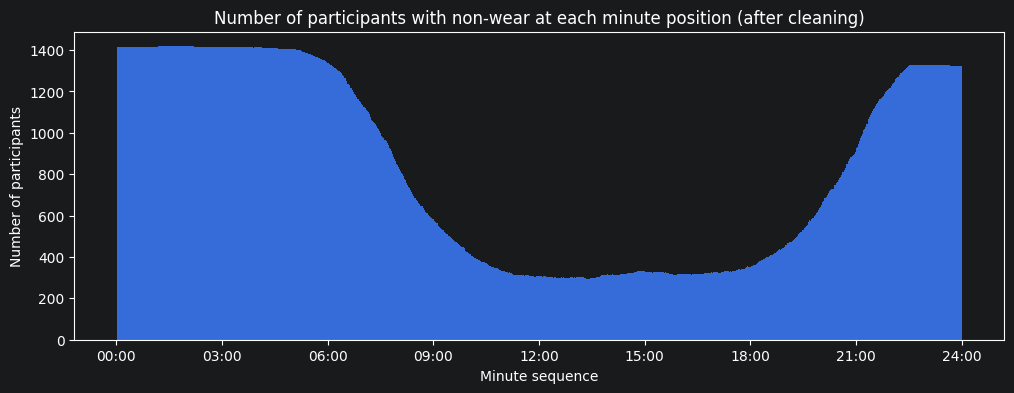

In [57]:
# non wear distribution plot after cleaning
non_wear_per_minute = (
    minute_metrics_06[minute_metrics_06["is_non_wear"] == True]
    .groupby("minute_sequence")["ID"]
    .nunique()
)

plt.figure(figsize=(12, 4))
plt.bar(non_wear_per_minute.index, non_wear_per_minute.values, width=1)
plt.xlabel("Minute sequence")
plt.ylabel("Number of participants")
plt.title("Number of participants with non-wear at each minute position (after cleaning)")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

## 4.4 Remove suspicious participant-days

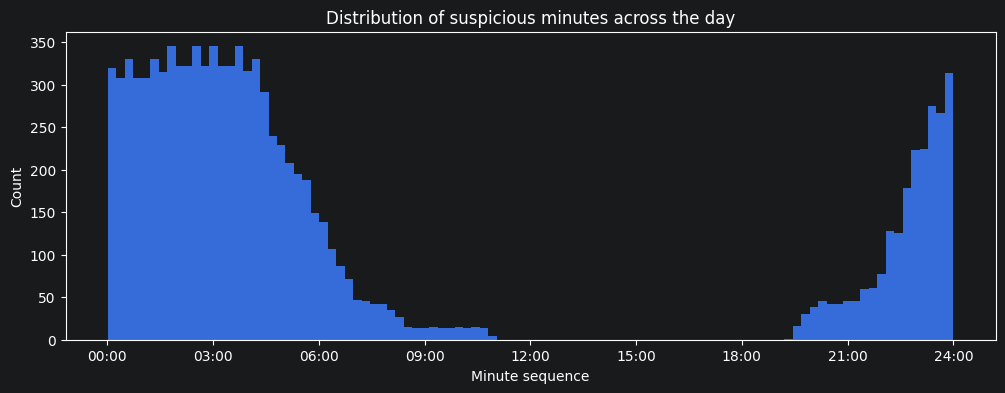

In [58]:
# Explore suspicious minutes distribution across the day

suspicious_minutes = (
    minute_metrics_06[
        minute_metrics_06["is_suspicious"] == True
    ]["minute_sequence"]
)

plt.figure(figsize=(12, 4))
plt.hist(suspicious_minutes, bins=100)
plt.xlabel("Minute sequence")
plt.ylabel("Count")
plt.title("Distribution of suspicious minutes across the day")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

In [59]:
# Drop only participant-days that contain any suspect minute, preserving each
# participant's remaining clean days. A single flagged minute is treated as
# compromising that day's rhythm fit, not the participant's entire record.

day_columns = ["ID", "study_day"]

suspect_participant_days = (
    minute_metrics_06.loc[minute_metrics_06["is_suspicious"] == True, day_columns]
    .drop_duplicates()
)

minutes_before = len(minute_metrics_06)
participants_before = minute_metrics_06["ID"].nunique()

# Anti-join: keep rows whose (ID, study day) is NOT in the suspect-day set.
minute_metrics_06 = (
    minute_metrics_06.merge(
        suspect_participant_days,
        on=day_columns,
        how="left",
        indicator=True,
    )
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
    .copy()
)

print(f"Suspect participant-days removed: {len(suspect_participant_days):,}")
print(f"Minutes dropped: {minutes_before - len(minute_metrics_06):,}")
print(f"Participants before: {participants_before:,}")
print(f"Participants after:  {minute_metrics_06['ID'].nunique():,}")

Suspect participant-days removed: 40
Minutes dropped: 57,600
Participants before: 1,419
Participants after:  1,419


## 4.5 Remove days with implausible wear time
Drop days with less than 10 hours of wear wear time to ensure stable harmonic regression fits

In [60]:
wear_time_per_day = (
    minute_metrics_06
    .groupby(["ID", "study_day"])["is_non_wear"]
    .apply(lambda x: (x == False).sum() / 60)
    .reset_index()
    .rename(columns={"is_non_wear": "wear_hours"})
)

invalid_days = wear_time_per_day[
    (wear_time_per_day["wear_hours"] < 10)
][["ID", "study_day"]]

minute_metrics_06 = minute_metrics_06[
    ~minute_metrics_06.set_index(["ID", "study_day"]).index.isin(
        invalid_days.set_index(["ID", "study_day"]).index
    )
].reset_index(drop=True)

print(f"Dropped {len(invalid_days):,} days.")
print(f"Remaining participants: {minute_metrics_06['ID'].nunique():,}")

Dropped 590 days.
Remaining participants: 1,414


## 4.6 Remove participants with <4 valid days

remember to justify why a 4-day minimum

In [61]:
days_per_participant = (
    minute_metrics_06
    .groupby("ID")["study_day"]
    .nunique()
)

valid_participants = days_per_participant[days_per_participant >= 4].index

participants_before = minute_metrics_06["ID"].nunique()
minute_metrics_06 = minute_metrics_06[minute_metrics_06["ID"].isin(valid_participants)].reset_index(drop=True)
participants_after = minute_metrics_06["ID"].nunique()

print(f"Dropped {participants_before - participants_after:,} participants with fewer than 4 valid days.")
print(f"Remaining participants: {participants_after:,}")

Dropped 57 participants with fewer than 4 valid days.
Remaining participants: 1,357


### Compare IDs between summary metric and minute metric datasets to check for any discrepancies after cleaning

In [62]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_06,
    second_dataframe=minute_metrics_06,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1357
Only in first: 54
Only in second: 0


### 4.7 Synchronise valid IDs across all dataframes

In [63]:
valid_ids_after_cleaning = set(minute_metrics_06["ID"].unique())

daily_metrics_06 = daily_metrics_06[
    daily_metrics_06["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

# summary_metrics_06 uses ID as index at this point in the pipeline
summary_metrics_06 = summary_metrics_06[
    summary_metrics_06["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

print(
    f"Participants after synchronisation:\n"
    f"  minute_metrics_06 : {minute_metrics_06['ID'].nunique():,}\n"
    f"  daily_metrics_06  : {daily_metrics_06['ID'].nunique():,}\n"
    f"  summary_metrics_06: {len(summary_metrics_06):,}"
)

Participants after synchronisation:
  minute_metrics_06 : 1,357
  daily_metrics_06  : 1,357
  summary_metrics_06: 1,357


In [64]:
print("Missing columns:")
total_rows = len(summary_metrics_06)
for col in final_outcome_variables:
    if col not in all_clinical_06_merged.columns:
        print(f"{col}: NOT PRESENT in dataframe")
        continue
    missing = summary_metrics_06[col].isna().sum()
    print(f"{col}: {missing}/{total_rows}")


Missing columns:
V06KOOSKPR: 0/1357
V06ICPTSKR: 24/1357
V06KOOSKPL: 0/1357
V06ICPTSKL: 24/1357
V0620MPACE: 36/1357
V06CSTIME1: 81/1357
V06400MTIM: 144/1357
V06400MTR: 143/1357
V06WOMADLR: 1/1357
V06KOOSYMR: 0/1357
V06WOMADLL: 1/1357
V06KOOSYML: 0/1357
V06CESD: 13/1357
V06LLDILST: 49/1357
V06LLDIFST: 16/1357
V06KOOSQOL: 1/1357


In [65]:
HIGH_MISSING_ITEM_GROUPS: dict[str, list[str]] = {
    "koos_sport_recreation": ["V06KOOSFSR"],
    "lldi_participation": ["V06LLDILST"],
    "four_hundred_metre_walk": ["V06400MTIM"],
}


def summarise_marginal_missingness(
    *,
    clinical_frame: pd.DataFrame,
    item_columns: list[str],
) -> pd.DataFrame:
    """Report the per-item missing count and rate.

    :param clinical_frame: One row per participant, containing the outcome items.
    :param item_columns: Outcome columns to summarise.
    :returns: Table indexed by item with missing count and percentage.
    """
    participant_count = len(clinical_frame)
    missing_count = clinical_frame[item_columns].isna().sum()
    summary = pd.DataFrame(
        {
            "missing_count": missing_count,
            "missing_percent": (100 * missing_count / participant_count).round(1),
        }
    )
    return summary.sort_values("missing_percent")


def build_pairwise_overlap_table(
    *,
    clinical_frame: pd.DataFrame,
    item_columns: list[str],
) -> pd.DataFrame:
    """Compare observed co-missingness against the MCAR expectation.

    For each ordered pair (row item, column item) the cell holds the share of
    the row item's missing participants that are also missing the column item.
    A value near 1.0 means the row item's missingness is nested inside the
    column item's, which is the signature of a skip pattern. A value near the
    column item's own marginal missing rate means the two are roughly
    independent, the signature of sporadic missingness.

    :param clinical_frame: One row per participant, containing the outcome items.
    :param item_columns: Outcome columns to cross-tabulate.
    :returns: Square table of conditional co-missingness shares.
    """
    is_missing = clinical_frame[item_columns].isna()
    overlap = pd.DataFrame(index=item_columns, columns=item_columns, dtype=float)

    for row_item in item_columns:
        row_missing_mask = is_missing[row_item]
        row_missing_total = int(row_missing_mask.sum())
        for column_item in item_columns:
            if row_missing_total == 0:
                overlap.loc[row_item, column_item] = np.nan
                continue
            both_missing = int((row_missing_mask & is_missing[column_item]).sum())
            overlap.loc[row_item, column_item] = both_missing / row_missing_total

    return overlap.round(2)


def report_structural_missingness(
    *,
    clinical_frame: pd.DataFrame,
    item_groups: dict[str, list[str]] = HIGH_MISSING_ITEM_GROUPS,
) -> None:
    """Print marginal rates, a co-missingness matrix, and a plain-language read.

    :param clinical_frame: One row per participant, containing the outcome items.
    :param item_groups: Named groups of items to include in the diagnostic.
    """
    item_columns = [column for group in item_groups.values() for column in group]
    present_columns = [column for column in item_columns if column in clinical_frame.columns]
    absent_columns = sorted(set(item_columns) - set(present_columns))
    if absent_columns:
        print(f"WARNING: columns not found and skipped: {absent_columns}\n")

    marginal = summarise_marginal_missingness(
        clinical_frame=clinical_frame, item_columns=present_columns
    )
    print("Marginal missingness")
    print(marginal, "\n")

    overlap = build_pairwise_overlap_table(
        clinical_frame=clinical_frame, item_columns=present_columns
    )
    print("Conditional co-missingness")
    print("(row i, col j) = share of participants missing item i who also miss item j")
    print(overlap, "\n")

    marginal_rate = marginal["missing_percent"] / 100
    lift_rows: dict[str, float] = {}
    for row_item in present_columns:
        other_items = [column for column in present_columns if column != row_item]
        observed_overlap = overlap.loc[row_item, other_items].astype(float).mean()
        expected_overlap = marginal_rate[other_items].mean()
        lift_rows[row_item] = round(float(observed_overlap - expected_overlap), 2)
    lift = pd.Series(lift_rows, name="co_missingness_lift").sort_values(ascending=False)
    print("Co-missingness lift over independence (higher => more structural)")
    print(lift)

In [66]:
report_structural_missingness(clinical_frame=all_clinical_06_merged)

Marginal missingness
            missing_count  missing_percent
V06LLDILST            487             13.3
V06400MTIM            565             15.4
V06KOOSFSR            976             26.6 

Conditional co-missingness
(row i, col j) = share of participants missing item i who also miss item j
            V06KOOSFSR  V06LLDILST  V06400MTIM
V06KOOSFSR        1.00        0.16        0.21
V06LLDILST        0.32        1.00        0.13
V06400MTIM        0.37        0.11        1.00 

Co-missingness lift over independence (higher => more structural)
V06KOOSFSR    0.04
V06400MTIM    0.04
V06LLDILST    0.01
Name: co_missingness_lift, dtype: float64


# 5. Activity feature engineering

## 5.1 Bout structure

In [67]:
def calculate_bout_structure(
        minute_dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculate bout structure parameters for each participant and study day
    from minute-level accelerometer data.

    For each intensity level, the following parameters are calculated:
        - bout_count:          number of uninterrupted episodes per day
        - bout_mean_duration:  mean duration of episodes in minutes
        - bout_max_duration:   longest episode in minutes
        - bout_total_minutes:  total minutes accumulated in episodes

    Intensity levels calculated:
        - sedentary:  < 100 counts/min
        - light:      100–2019 counts/min
        - moderate:   2020–5998 counts/min
        - vigorous:   >= 5999 counts/min
        - mvpa:       moderate + vigorous (>= 2020 counts/min)
        - active:     light + moderate + vigorous (>= 100 counts/min)

    Non-wear and suspicious minutes are excluded before calculation.
    A bout is defined as consecutive minutes of the same intensity level
    with no tolerance for interruptions.
    """

    required_columns =[
        "ID",
        "study_day",
        "counts",
        "minute_sequence",
        "is_non_wear",
        "is_suspicious",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    intensity_level_definition = {
        "sedentary": lambda counts: counts < 100,
        "light": lambda counts: (counts >= 100) & (counts < 2020),
        "moderate": lambda counts: (counts >= 2020) & (counts < 5999),
        "vigorous": lambda counts: counts >= 5999,
        "mvpa": lambda counts: counts >= 2020,
        "active": lambda counts: counts >= 100,
    }

    valid_minutes = minute_dataframe[
        ~minute_dataframe["is_non_wear"]
        & ~minute_dataframe["is_suspicious"]
    ].copy()

    valid_minutes = valid_minutes.dropna(subset=["counts"])

    results = []

    for (participant_id, study_day), group in valid_minutes.groupby(["ID", "study_day"]
    ):
        day_result = {
            "ID": participant_id,
            "study_day": study_day,
        }

        for intensity_level, intensity_condition in intensity_level_definition.items():
            bout_duration = extract_bout_duration(
                counts=group["counts"],
                minute_sequence=group["minute_sequence"],
                intensity_condition=intensity_condition,
            )

            if len(bout_duration) == 0:
                day_result[f"{intensity_level}_bout_count"] = 0
                day_result[f"{intensity_level}_bout_mean_duration"] = 0.0
                day_result[f"{intensity_level}_bout_max_duration"] = 0.0
                day_result[f"{intensity_level}_bout_total_minutes"] = 0.0
            else:
                day_result[f"{intensity_level}_bout_count"] = len(bout_duration)
                day_result[f"{intensity_level}_bout_mean_duration"] = np.mean(bout_duration)
                day_result[f"{intensity_level}_bout_max_duration"] = np.max(bout_duration)
                day_result[f"{intensity_level}_bout_total_minutes"] = np.sum(bout_duration)

        results.append(day_result)

    return pd.DataFrame(results)

def extract_bout_duration(
        counts: pd.Series,
        minute_sequence: pd.Series,
        intensity_condition: callable,
        expected_minute_step: int = 1,
) -> list[int]:

    """
    Extract the duration of each uninterrupted bout matching the given
    intensity condition from a minute-level counts series.

    A bout is a sequence of consecutive minutes for which the intensity
    condition is met *and* which are adjacent in time. A bout is broken
    whenever the intensity condition fails, or whenever the gap between
    two successive retained minutes exceeds ``expected_minute_step`` (for
    example because a non-wear, suspicious, or missing minute was removed
    upstream).

    :param counts: Minute-level activity counts.
    :param minute_sequence: Within-day minute position for each minute,
        index-aligned with ``counts``.
    :param intensity_condition: Callable mapping a counts series to a
        boolean series that is ``True`` where the minute matches the
        target intensity.
    :param expected_minute_step: Maximum allowed difference in
        ``minute_sequence`` between two successive minutes for them to
        count as adjacent. Defaults to one minute.
    :returns: Duration in minutes of each bout, in order of occurrence.
    """

    minute_frame = pd.DataFrame({
        "minute_sequence": minute_sequence,
        "is_intensity": intensity_condition(counts),
    }).sort_values("minute_sequence").reset_index(drop=True)

    bout_durations = []
    current_bout_duration = 0
    previous_minute_sequence = None

    for minute_position, is_active in zip(
            minute_frame["minute_sequence"], minute_frame["is_intensity"]
    ):
        is_adjacent = (
            previous_minute_sequence is not None
            and (minute_position - previous_minute_sequence) <= expected_minute_step
        )

        # A time gap ends the current bout even if this minute also
        # matches the intensity condition.
        if is_active and current_bout_duration > 0 and not is_adjacent:
            bout_durations.append(current_bout_duration)
            current_bout_duration = 0

        if is_active:
            current_bout_duration += 1
        else:
            if current_bout_duration > 0:
                bout_durations.append(current_bout_duration)
            current_bout_duration = 0

        previous_minute_sequence = minute_position

    if current_bout_duration > 0:
        bout_durations.append(current_bout_duration)

    return bout_durations

In [68]:
# calculate bout structure

bout_structure_daily = calculate_bout_structure(minute_dataframe=minute_metrics_06)

# merge into daily_metrics_06
daily_metrics_06 = daily_metrics_06.merge(
    bout_structure_daily,
    left_on=["ID", "V06PAStudyDay"],
    right_on=["ID", "study_day"],
    how="left",
)

# aggregate to summary level
bout_structure_summary = (
    bout_structure_daily
    .groupby("ID")
    .agg({
        col: "mean"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
    .reset_index()
    .rename(columns={
        col: f"mean_{col}"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
)

# merge into summary_metrics_06
summary_metrics_06 = summary_metrics_06.merge(
    bout_structure_summary,
    on="ID",
    how="left",
)

In [69]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

## 5.2 WHO guideline compliance

In [70]:
def calculate_who_guideline_compliance(daily_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate WHO guideline compliance for each day based on daily activity metrics.
    WHO guidelines for adults recommend:
        - At least 150 minutes of moderate-intensity aerobic physical activity per week, or
        - At least 75 minutes of vigorous-intensity aerobic physical activity per week, or
        - An equivalent combination of moderate- and vigorous-intensity activity.

    This function adds a column to the daily_metrics_df indicating whether the
    participant met the WHO guidelines on that day and a column to the summary_metrics if the WHO (schreibe genau was es macht)
    """

    required_columns = [
        "ID",
        "V06DAYModMinT",
        "V06DAYVigMinT",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in daily_dataframe.columns
    ]
    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    daily_moderate_guideline_threshold = 150/7
    daily_vigorous_guideline_threshold = 75/7
    weekly_moderate_guideline_threshold = 150
    weekly_vigorous_guideline_threshold = 75
    vigorous_to_moderate_multiplier = 2

    result_dataframe = daily_dataframe.copy()

    result_dataframe["combined_equivalent_minutes"] = (result_dataframe["V06DAYModMinT"] + result_dataframe["V06DAYVigMinT"] * vigorous_to_moderate_multiplier)

    result_dataframe["meets_daily_who_guideline"] = (
    (result_dataframe["V06DAYModMinT"] >= daily_moderate_guideline_threshold)
    | (result_dataframe["V06DAYVigMinT"] >= daily_vigorous_guideline_threshold)
    | (result_dataframe["combined_equivalent_minutes"] >= daily_moderate_guideline_threshold)
    )

    weekly_compliance = result_dataframe.groupby("ID").agg(
        total_moderate_minutes=("V06DAYModMinT", "sum"),
        total_vigorous_minutes=("V06DAYVigMinT", "sum"),
        total_combined_equivalent_minutes=("combined_equivalent_minutes", "sum"),
        day_count=("combined_equivalent_minutes", "count"),
    ).reset_index()

    weekly_compliance["meets_weekly_who_guideline"] = (
    (weekly_compliance["total_moderate_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
    | (weekly_compliance["total_vigorous_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_vigorous_guideline_threshold)
    | (weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
)

    weekly_compliance["weekly_guideline_gap_minutes"] = (
    weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7
    - weekly_moderate_guideline_threshold
)
    result_dataframe = result_dataframe.merge(
        weekly_compliance[[
            "ID",
            "meets_weekly_who_guideline",
            "weekly_guideline_gap_minutes",
        ]],
        on="ID",
        how="left",
    )

    return result_dataframe

In [71]:
daily_metrics_06 = calculate_who_guideline_compliance(
    daily_dataframe=daily_metrics_06,
)

In [72]:
summary_metrics_06 = summary_metrics_06.merge(
    daily_metrics_06[["ID", "meets_weekly_who_guideline", "weekly_guideline_gap_minutes"]]
    .drop_duplicates(subset="ID"),
    on="ID",
    how="left",
)

In [73]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

In [74]:
participant_compliance = daily_metrics_06.groupby("ID")["meets_weekly_who_guideline"].first()

total = len(participant_compliance)
meets_true = participant_compliance.sum()
meets_false = total - meets_true

print(f"Total participants: {total}")
print(f"Meets WHO guideline: {meets_true} ({meets_true/total:.1%})")
print(f"Does not meet WHO guideline: {meets_false} ({meets_false/total:.1%})")

Total participants: 1357
Meets WHO guideline: 421 (31.0%)
Does not meet WHO guideline: 936 (69.0%)


## 5.3 Activity onset / offset

In [75]:
def compute_activity_onset_offset_time(df: pd.DataFrame, id_col: str = "ID", day_col: str = "study_day",
                                       min_col: str = "minute_sequence", activity_count_col: str = "counts",
                                       suspect_col: str = "is_suspicious") -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    computes activity onset (first active minute) and activity offset (last active minute) per ID and day
    Returns:
        daily_activity_onset_offset_metrics: ID, Day, activity_onset_minute, activity_offset_minute, onset_time_hhmm, offset_time_hhmm
        id_agg_sctivity_onset_offset_metrics: ID, aggregated onset/offset mean and sds
    """

# function to convert minute of day to HH:MM format, minute 1 = 00:01, minute 1440 = 24:00

    def minute_to_hhmm(m):
        if pd.isna(m):
            return np.nan
        h = int((m - 1) // 60)
        mins = int((m - 1) % 60)
        return f"{h:02d}:{mins:02d}"

    results = []

# filter per ID and day, only non-suspect minutes, sort by minute sequence, find first and last active minute (activity count > 0)

    for (id, day), grp in df.groupby([id_col, day_col]):

        grp_filtered = grp[grp[suspect_col] == 0].sort_values(min_col)
        active = grp_filtered[grp_filtered[activity_count_col] > 0][min_col].values

        if len(active) == 0:
            results.append({
                id_col: id,
                day_col: day,
                "activity_onset_minute": np.nan,
                "activity_offset_minute": np.nan,
            })
            continue

        results.append({
            id_col: id,
            day_col: day,
            "activity_onset_minute": active[0],  # first active minute
            "activity_offset_minute": active[-1],  # last active minute
        })

    daily_activity_onset_offset_metrics = pd.DataFrame(results)

    daily_activity_onset_offset_metrics["onset_time_hhmm"] = daily_activity_onset_offset_metrics["activity_onset_minute"].apply(minute_to_hhmm)
    daily_activity_onset_offset_metrics["offset_time_hhmm"] = daily_activity_onset_offset_metrics["activity_offset_minute"].apply(minute_to_hhmm)
    daily_activity_onset_offset_metrics["wear_duration_min"] = daily_activity_onset_offset_metrics["activity_offset_minute"] - daily_activity_onset_offset_metrics["activity_onset_minute"]

    # aggregate per ID across days

    id_agg_activity_onset_offset_metrics = (
        daily_activity_onset_offset_metrics.groupby(id_col).agg(
            activity_onset_minute_mean=("activity_onset_minute", np.mean),
            activity_onset_minute_sd=("activity_onset_minute", np.std),
            activity_offset_minute_mean=("activity_offset_minute", np.mean),
            activity_offset_minute_sd=("activity_offset_minute", np.std),
            wear_duration_mean=("wear_duration_min", np.mean),
            valid_days_derived=("activity_onset_minute", "count"),
        )
        .reset_index()
    )

    id_agg_activity_onset_offset_metrics["onset_mean_hhmm"] = id_agg_activity_onset_offset_metrics["activity_onset_minute_mean"].apply(minute_to_hhmm)
    id_agg_activity_onset_offset_metrics["offset_mean_hhmm"] = id_agg_activity_onset_offset_metrics["activity_offset_minute_mean"].apply(minute_to_hhmm)

    return daily_activity_onset_offset_metrics, id_agg_activity_onset_offset_metrics

In [76]:
daily_activity_onset_offset_metrics_06, id_agg_activity_onset_offset_metrics_06 = compute_activity_onset_offset_time(minute_metrics_06)
summary_metrics_06 = summary_metrics_06.merge(id_agg_activity_onset_offset_metrics_06, on="ID", how="left")
daily_metrics_06 = daily_metrics_06.merge(daily_activity_onset_offset_metrics_06, on=["ID", "study_day"], how="left")

In [77]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### Explore valid days per ID / discrepancies between valid days in summary_metrics_06 and minute_metrics_06

In [78]:
discrepant = summary_metrics_06[
    summary_metrics_06["valid_days_derived"] != summary_metrics_06["valid_days_oai"]
][["ID", "valid_days_derived", "valid_days_oai", "wear_duration_mean"]].dropna()

print(f"Number of discrepant participants: {len(discrepant)}")
print(discrepant.sort_values("ID"))
print(discrepant.shape)

# separately check how many have mean wear duration under 600 minutes (10 hours)
under_600 = discrepant[discrepant["wear_duration_mean"] < 600]
print(f"\nParticipants with mean wear duration under 600 minutes: {len(under_600)}")
print(under_600.sort_values("wear_duration_mean"))
print(under_600.shape)

# check suspicious minutes for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

suspicious_summary = (
    minute_metrics_06[minute_metrics_06["ID"].isin(discrepant_ids)]
    .groupby("ID")["is_suspicious"]
    .agg(
        total_minutes="count",
        suspicious_minutes="sum",
    )
    .assign(
        suspicious_percent=lambda x: (x["suspicious_minutes"] / x["total_minutes"] * 100).round(1)
    )
    .reset_index()
)

discrepant = discrepant.merge(suspicious_summary, on="ID", how="left")

print(f"\nDiscrepant participants with suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False))
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False).shape)
print(f"\nDiscrepant participants without suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID"))
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID").shape)

# participants that are both suspicious AND under 600 minutes wear duration
print(f"\nDiscrepant participants with suspicious minutes AND under 600 minutes wear duration:")
suspicious_and_under_600 = discrepant[
    (discrepant["suspicious_minutes"] > 0)
    & (discrepant["wear_duration_mean"] < 600)
]
print(suspicious_and_under_600.sort_values("wear_duration_mean"))
print(suspicious_and_under_600.shape)


Number of discrepant participants: 1357
           ID  valid_days_derived valid_days_oai  wear_duration_mean
0     9002116                  11              6         1295.636364
1     9002430                   7              7          939.714286
2     9002817                   7              7          932.857143
3     9003126                   5              5         1197.400000
4     9004184                   5              4         1387.200000
...       ...                 ...            ...                 ...
1352  9996865                   7              7          989.571429
1353  9997610                   7              7          943.428571
1354  9998089                   7              7          986.857143
1355  9998384                   7              7          839.571429
1356  9999878                   7              7          844.571429

[1357 rows x 4 columns]
(1357, 4)

Participants with mean wear duration under 600 minutes: 0
Empty DataFrame
Columns: [ID, valid_da

In [79]:
print(summary_metrics_06[summary_metrics_06["valid_days_derived"] > 7].shape)

(41, 67)


In [80]:
# count all days per participant from minute data
all_days_from_minutes = (
    minute_metrics_06
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "total_days_minute_data"})
)

# count valid days per participant from minute data
# a day is valid if it has at least one non-suspicious, non-wear minute
valid_days_from_minutes = (
    minute_metrics_06[
        ~minute_metrics_06["intensity_label"].isin(["non_wear", "suspicious"])
    ]
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "valid_days_minute_data"})
)

# count days per participant from daily data (OAI valid days)
oai_valid_days = (
    daily_metrics_06
    .groupby("ID")["V06PAStudyDay"]
    .nunique()
    .reset_index()
    .rename(columns={"V06PAStudyDay": "oai_valid_days"})
)

# merge all three together with valid_days_oai from summary
day_comparison = (
    summary_metrics_06[["ID", "valid_days_oai"]]
    .merge(all_days_from_minutes, on="ID", how="left")
    .merge(valid_days_from_minutes, on="ID", how="left")
    .merge(oai_valid_days, on="ID", how="left")
)

# add difference columns to understand exclusion reasons
day_comparison["days_excluded_total"] = (
    day_comparison["total_days_minute_data"] - day_comparison["oai_valid_days"]
)
day_comparison["days_excluded_nonwear_or_suspicious"] = (
    day_comparison["total_days_minute_data"] - day_comparison["valid_days_minute_data"]
)
day_comparison["days_excluded_oai_cap"] = (
    day_comparison["valid_days_minute_data"] - day_comparison["oai_valid_days"]
)

print(f"Total participants: {len(day_comparison)}")
print(f"\nDay comparison statistics:")
print(day_comparison[[
    "total_days_minute_data",
    "valid_days_minute_data",
    "oai_valid_days",
    "valid_days_oai",
    "days_excluded_total",
    "days_excluded_nonwear_or_suspicious",
    "days_excluded_oai_cap",
]].describe())

print(f"\nParticipants with discrepancies:")
discrepant = day_comparison[
    day_comparison["valid_days_minute_data"] != day_comparison["oai_valid_days"]
].dropna()
print(f"Total discrepant: {len(discrepant)}")
print(discrepant.sort_values("days_excluded_total", ascending=False))

Total participants: 1357

Day comparison statistics:
       total_days_minute_data  valid_days_minute_data  oai_valid_days  \
count             1357.000000             1357.000000     1357.000000   
mean                 6.790715                6.790715        6.676492   
std                  0.666609                0.666609        0.710737   
min                  4.000000                4.000000        1.000000   
25%                  7.000000                7.000000        7.000000   
50%                  7.000000                7.000000        7.000000   
75%                  7.000000                7.000000        7.000000   
max                 11.000000               11.000000        7.000000   

       days_excluded_total  days_excluded_nonwear_or_suspicious  \
count          1357.000000                               1357.0   
mean              0.114223                                  0.0   
std               0.511876                                  0.0   
min              -3.0

In [81]:
# get day-level data for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

# get all days from minute data for discrepant participants
discrepant_days = daily_activity_onset_offset_metrics_06[
    daily_activity_onset_offset_metrics_06["ID"].isin(discrepant_ids)
][["ID", "study_day", "wear_duration_min"]]

# add suspicious minutes per day
suspicious_per_day = (
    minute_metrics_06[minute_metrics_06["ID"].isin(discrepant_ids)]
    .groupby(["ID", "study_day"])["is_suspicious"]
    .sum()
    .reset_index()
    .rename(columns={"study_day": "study_day", "is_suspicious": "suspicious_minutes"})
)

discrepant_days = discrepant_days.merge(suspicious_per_day, on=["ID", "study_day"], how="left")

# flag days that are in minute data but NOT in daily_metrics_06 (excluded by OAI)
oai_days = daily_metrics_06[["ID", "study_day"]].drop_duplicates()
oai_days["in_oai_daily"] = True

discrepant_days = discrepant_days.merge(oai_days, on=["ID", "study_day"], how="left")
discrepant_days["in_oai_daily"] = discrepant_days["in_oai_daily"].fillna(False)

# only look at excluded days
excluded_days = discrepant_days[discrepant_days["in_oai_daily"] == False]

print(f"Total excluded days across discrepant participants: {len(excluded_days)}")
print(f"\nExclusion reasons:")
print(f"Days with suspicious minutes > 0: {(excluded_days['suspicious_minutes'] > 0).sum()} ({(excluded_days['suspicious_minutes'] > 0).mean():.1%})")
print(f"Days with wear duration < 600 min: {(excluded_days['wear_duration_min'] < 600).sum()} ({(excluded_days['wear_duration_min'] < 600).mean():.1%})")
print(f"Days with both suspicious AND < 600 min: {((excluded_days['suspicious_minutes'] > 0) & (excluded_days['wear_duration_min'] < 600)).sum()}")
print(f"Days with neither reason (OAI 7-day cap): {((excluded_days['suspicious_minutes'] == 0) & (excluded_days['wear_duration_min'] >= 600)).sum()}")

Total excluded days across discrepant participants: 181

Exclusion reasons:
Days with suspicious minutes > 0: 0 (0.0%)
Days with wear duration < 600 min: 1 (0.6%)
Days with both suspicious AND < 600 min: 0
Days with neither reason (OAI 7-day cap): 180


## 5.4 Harmonic regression

Fit harmonic regression model to each participant's minute-level data and extract activity profile features five features per participant.
Three from harmonic regression (MESOR, amplitude, acrophase) describing
the *shape* of the average daily rhythm. Two nonparametric indices
(IV, IS) describing within-day fragmentation and between-day consistency,
which the harmonic fit cannot capture by construction.

## 5.4.1 Mean daily curve

In [82]:
# gropupby ID, minute_sequence

mean_daily_curve = (
    minute_metrics_06
    .groupby(["ID", "minute_sequence"])["counts"]
    .mean()
    .reset_index()
    .rename(columns={"counts": "mean_counts"})
)

print(f"Mean daily curve computed for {mean_daily_curve['ID'].nunique():,} participants.")
print(mean_daily_curve.head())

Mean daily curve computed for 1,357 participants.
        ID  minute_sequence  mean_counts
0  9002116                1     0.000000
1  9002116                2     0.000000
2  9002116                3     0.000000
3  9002116                4     0.454545
4  9002116                5     0.363636


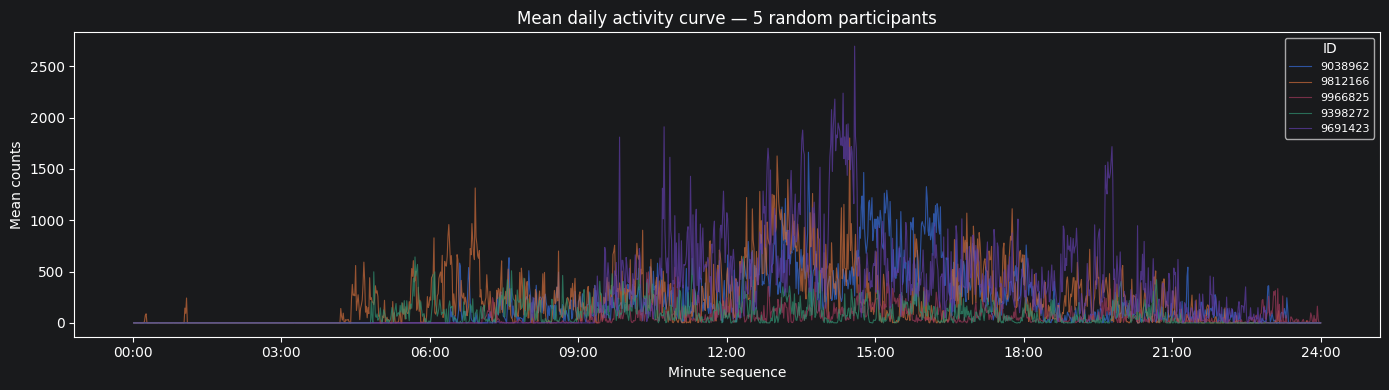

In [83]:
# Plot mean daily curve for a few random participants to verify the shape (sanity check)

sample_ids = mean_daily_curve["ID"].drop_duplicates().sample(5, random_state=42)

fig, ax = plt.subplots(figsize=(14, 4))

for participant_id in sample_ids:
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    ax.plot(
        participant_curve["minute_sequence"],
        participant_curve["mean_counts"],
        alpha=0.7,
        linewidth=0.8,
        label=str(participant_id),
    )

ax.set_xlabel("Minute sequence")
ax.set_ylabel("Mean counts")
ax.set_title("Mean daily activity curve — 5 random participants")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend(title="ID", fontsize=8)
plt.tight_layout()
plt.show()

### 5.4.2 Single participant demonstration

intercept (MESOR) plus two harmonic
pairs at periods of 24h and 12h, fitted with ordinary least squares.
Note that acrophase is read from argmax of the fitted curve rather
than from arctan2 of the coefficients to avoid sign-convention bugs.

In [84]:
# manual fit for single participant

participant_id = 9002116

single_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]

minutes = single_curve["minute_sequence"].to_numpy(dtype=float)
counts = single_curve["mean_counts"].to_numpy(dtype=float)

# Build design matrix: intercept + 2 harmonic pairs
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),                                    # MESOR
    np.cos(2 * np.pi * 1 * minutes / period),                # harmonic 1 cosine
    np.sin(2 * np.pi * 1 * minutes / period),                # harmonic 1 sine
    np.cos(2 * np.pi * 2 * minutes / period),                # harmonic 2 cosine
    np.sin(2 * np.pi * 2 * minutes / period),                # harmonic 2 sine
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
# Read acrophase directly from the peak of the fitted curve
# rather than computing from arctan2 to avoid sign convention issues
fitted_counts = design_matrix @ coefficients
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f} hours ({int(peak_minute // 60):02d}:{int(peak_minute % 60):02d})")

MESOR: 53.17
Amplitude: 53.27
Acrophase: 16.80 hours (16:48)


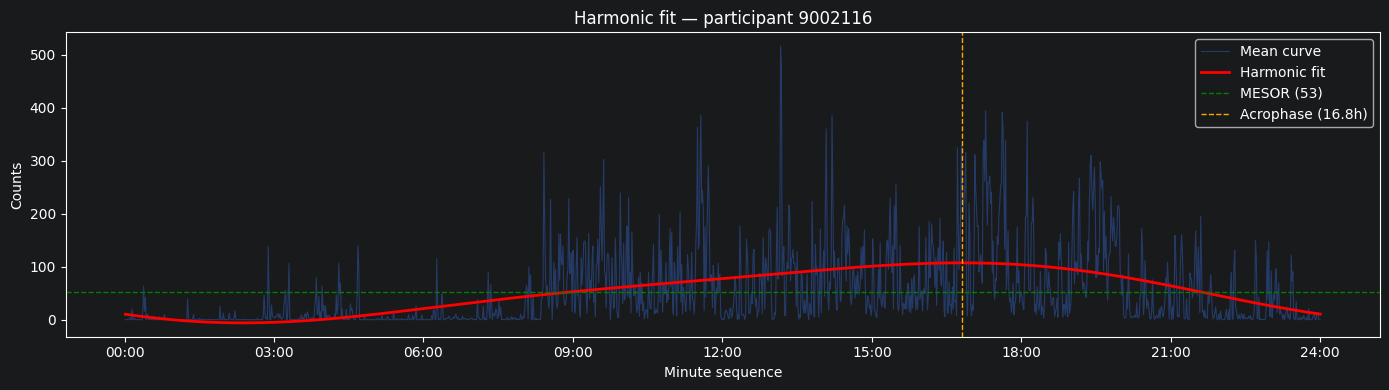

In [85]:
# plot showing curve, fit, MESOR line, acrophase line

fitted_counts = design_matrix @ coefficients

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
ax.axhline(y=mesor, color="green", linestyle="--", linewidth=1, label=f"MESOR ({mesor:.0f})")
ax.axvline(x=acrophase_hours * 60, color="orange", linestyle="--", linewidth=1, label=f"Acrophase ({acrophase_hours:.1f}h)")
ax.set_xlabel("Minute sequence")
ax.set_ylabel("Counts")
ax.set_title(f"Harmonic fit — participant {participant_id}")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend()
plt.tight_layout()
plt.show()


### 5.4.3 Fit to all participants (MESOR, amplitude, acrophase)

In [86]:
# fit_harmonic_model function

def fit_harmonic_model(
        mean_daily_curve: pd.DataFrame,
        column_id: str,
        column_minute_sequence: str,
        column_mean_counts: str,
        period: int = 1440,
        number_of_harmonics: int = 2,
) -> pd.DataFrame:

    # Fit a harmonic regression model to each participant's mean daily curve and extract MESOR, amplitude, and acrophase.

    records = []

    for participant_id, participant_curve in mean_daily_curve.groupby(column_id):
        minutes = participant_curve[column_minute_sequence].to_numpy(dtype=float)
        counts = participant_curve[column_mean_counts].to_numpy(dtype=float)

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)

        fitted_counts = design_matrix @ coefficients
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hour = peak_minute /60

        records.append({
            column_id: participant_id,
            "mesor":mesor,
            "amplitude":amplitude,
            "acrophase":acrophase_hour,
        })

    return pd.DataFrame(records).set_index(column_id)

harmonic_features = fit_harmonic_model(
    mean_daily_curve = mean_daily_curve,
    column_id = "ID",
    column_minute_sequence = "minute_sequence",
    column_mean_counts = "mean_counts",
)

print(f"Harmonic features extracted for {len(harmonic_features)} participants:")
print(harmonic_features.describe())


Harmonic features extracted for 1357 participants:
             mesor    amplitude    acrophase
count  1357.000000  1357.000000  1357.000000
mean    148.033060   153.707892    12.434844
std      73.997115    83.533894     2.925283
min      13.250417    11.082492     3.750000
25%      94.636607    96.355939    10.466667
50%     131.252480   133.804423    11.966667
75%     190.847718   195.522447    14.250000
max     523.245734   711.080432    23.666667


### 5.4.4 Acrophase distribution / outlier inspection

describe what an extreme acrophase means (needs to be done) — peak before 6am
    or after 8pm is unusual and worth visual inspection. Document the
    decision: keep

In [87]:
# find participants with acrophase < 6 or > 20

print(harmonic_features[harmonic_features["acrophase"] < 6])
print(harmonic_features[harmonic_features["acrophase"] > 20])

              mesor   amplitude  acrophase
ID                                        
9540125  213.689683  159.091218   5.183333
9547559  189.666270  133.837106   5.733333
9618669  142.020635  152.269939   4.016667
9850328  187.250992  148.203624   3.750000
              mesor   amplitude  acrophase
ID                                        
9011661  290.622338  266.999324  20.983333
9068197  245.167063  176.132539  20.166667
9093126   53.990774   40.700721  20.433333
9120358  335.321429   75.670989  23.666667
9835291  207.147222  187.285765  20.816667


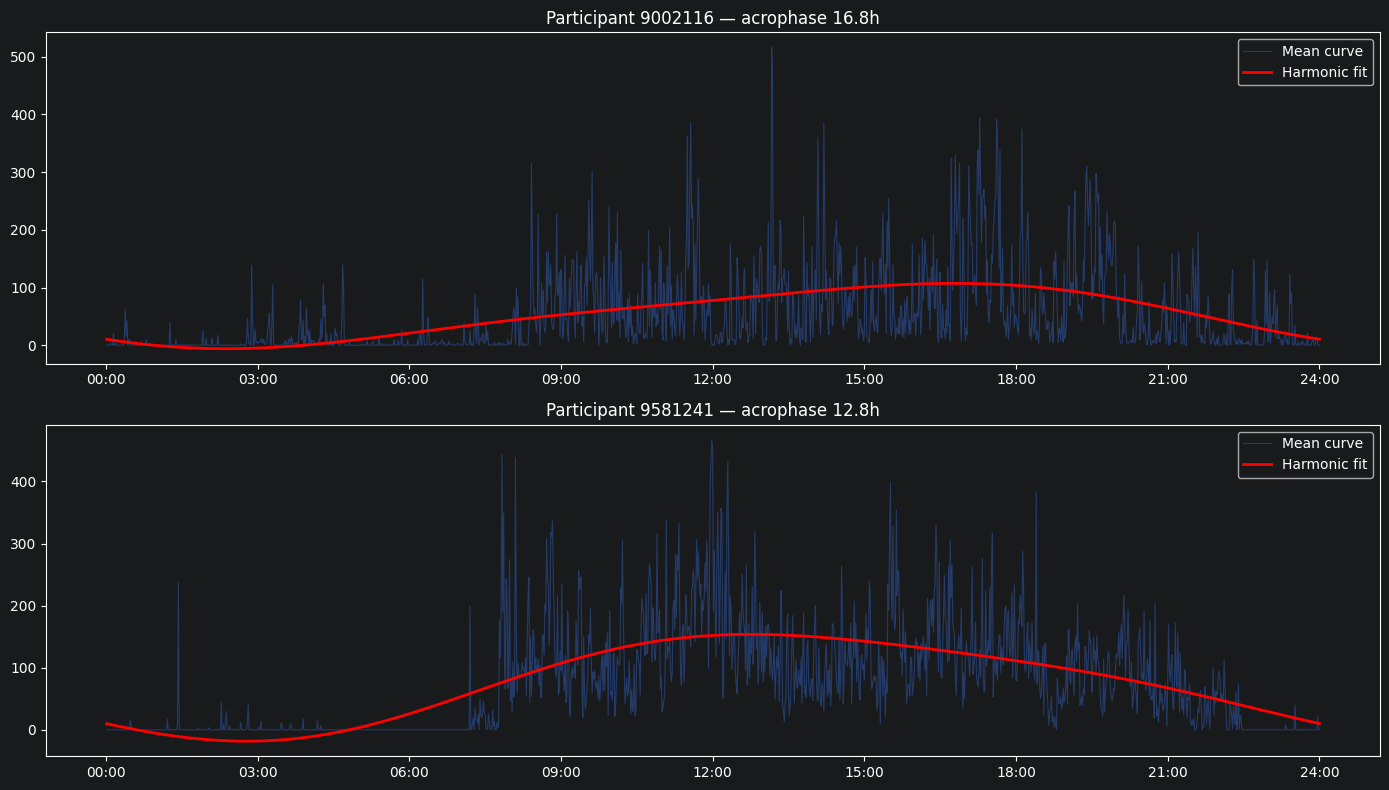

In [88]:
# Plot two outlier examples

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8))

for ax, participant_id in zip(axes, [9002116, 9581241]):
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    minutes = participant_curve["minute_sequence"].to_numpy(dtype=float)
    counts = participant_curve["mean_counts"].to_numpy(dtype=float)

    design_matrix = np.column_stack([
        np.ones(len(minutes)),
        np.cos(2 * np.pi * 1 * minutes / 1440),
        np.sin(2 * np.pi * 1 * minutes / 1440),
        np.cos(2 * np.pi * 2 * minutes / 1440),
        np.sin(2 * np.pi * 2 * minutes / 1440),
    ])
    coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
    fitted_counts = design_matrix @ coefficients

    ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
    ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
    ax.set_title(f"Participant {participant_id} — acrophase {harmonic_features.loc[participant_id, 'acrophase']:.1f}h")
    ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
    ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
    ax.legend()

plt.tight_layout()
plt.show()

## 5.5 Rhythm indicies: Intradaily Variability (IV) and Interdaily Stability (IS)

Harmonic regression describes the *shape* of the daily activity rhythm (when does
the person peak, how active are they on average). IV and IS describe two complementary
dimensions that harmonic parameters cannot capture:

IV: Within-day fragmentation — how much does the person's activity fluctuate up and down across the day?
    - High IV = lots of short bursts of activity interspersed with rest (frequent stop-and-go pattern)
    - Low IV = more consolidated activity and rest periods (smooth, sustained activity pattern)

IS: Day-to-day consistency — how similar is the person's activity pattern across different days?
    - High IS = very regular routine, similar activity levels at the same times each day
    - Low IS = irregular routine, varying activity levels and timing across days

Technical note
IV and IS are computed from the **raw minute-level data across all valid days**,
not from the mean daily curve. This is intentional, both indices specifically
quantify variability over time, which the mean curve averages away by design.

### 5.5.1 IV / IS single participant demonstration

In [89]:
participant_id = 9581241

participant_data = (
    minute_metrics_06[minute_metrics_06["ID"] == participant_id]
    .sort_values(["study_day", "minute_sequence"])
)

counts = participant_data["counts"].to_numpy(dtype=float)

# IV: ratio of mean squared first-order differences to overall variance
# n * sum of squared differences between consecutive minutes
# divided by (n-1) * overall variance
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)

iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"IV for participant {participant_id}: {iv:.4f}")

IV for participant 9581241: 0.9386


In [90]:
# IS: ratio of variance of the mean 24h profile to overall variance
# Reshape counts into a matrix of days x minutes
number_of_complete_days = len(counts) // 1440
trimmed_counts = counts[:number_of_complete_days * 1440]
reshaped = trimmed_counts.reshape(number_of_complete_days, 1440)

# Mean activity at each of the 1440 minute positions across all days
mean_24h_profile = np.mean(reshaped, axis=0)
overall_mean = np.mean(trimmed_counts)

profile_variance = np.sum((mean_24h_profile - overall_mean) ** 2)
overall_variance = np.sum((trimmed_counts - overall_mean) ** 2)

is_index = (number_of_complete_days * profile_variance) / overall_variance

print(f"IS for participant {participant_id}: {is_index:.4f}")

IS for participant 9581241: 0.2101


### 5.5.2 Apply IV / IS to all participants

In [91]:
# compute_iv_and_is function
def compute_iv_and_is(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    minutes_per_day: int = 1440,
) -> pd.DataFrame:
    """
    Compute intradaily variability (IV) and interdaily stability (IS)
    for each participant from the raw minute-level activity data.

    IV and IS are computed from the raw multi-day signal rather than
    the mean daily curve because both indices specifically quantify
    variability over time, which the mean curve averages away.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param minutes_per_day: Number of minutes per day (1440).
    :return: DataFrame indexed by participant ID with columns
        [intradaily_variability, interdaily_stability].
    """
    records = []

    for participant_id, participant_data in minute_dataframe.groupby(column_id):
        participant_data = participant_data.sort_values(
            by=[column_study_day, column_minute_sequence]
        )
         # Fill residual NaN values with 0 before computing variance-based indices
        counts = participant_data[column_counts].to_numpy(dtype=float)
        counts = np.nan_to_num(counts, nan=0.0)

        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)

        # IV
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

        # IS
        number_of_complete_days = number_of_minutes // minutes_per_day
        trimmed_counts = counts[:number_of_complete_days * minutes_per_day]
        reshaped = trimmed_counts.reshape(number_of_complete_days, minutes_per_day)
        mean_24h_profile = np.mean(reshaped, axis=0)
        overall_mean_trimmed = np.mean(trimmed_counts)
        profile_variance = np.sum((mean_24h_profile - overall_mean_trimmed) ** 2)
        overall_variance_trimmed = np.sum((trimmed_counts - overall_mean_trimmed) ** 2)
        is_index = (number_of_complete_days * profile_variance) / overall_variance_trimmed

        records.append({
            column_id: participant_id,
            "intradaily_variability": iv,
            "interdaily_stability": is_index,
        })

    return pd.DataFrame(records).set_index(column_id)

# apply function
rhythm_indices = compute_iv_and_is(
    minute_dataframe=minute_metrics_06,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

# describe IV an IS
print(f"IV and IS computed for {len(rhythm_indices)} participants.")
print(rhythm_indices.describe())

IV and IS computed for 1357 participants.
       intradaily_variability  interdaily_stability
count             1357.000000           1357.000000
mean                 0.655254              0.231621
std                  0.243178              0.050386
min                  0.051319              0.114754
25%                  0.481176              0.198931
50%                  0.671778              0.221350
75%                  0.837984              0.253882
max                  1.417876              0.616200


### Merge features into the summary metrics_06

In [92]:
summary_metrics_06 = summary_metrics_06.set_index("ID")

summary_metrics_06 = summary_metrics_06.join(harmonic_features, how="left")
summary_metrics_06 = summary_metrics_06.join(rhythm_indices, how="left")

print(f"Summary data shape after merging: {summary_metrics_06.shape}")
print(f"Missing values for new features:")
print(summary_metrics_06[["mesor", "amplitude", "acrophase",
                           "intradaily_variability", "interdaily_stability"]].isna().sum())

Summary data shape after merging: (1357, 71)
Missing values for new features:
mesor                     0
amplitude                 0
acrophase                 0
intradaily_variability    0
interdaily_stability      0
dtype: int64


## 5.6 Per-day harmonic decomposition

Single-day demonstration for on participant

In [93]:
participant_id = 9581241
study_day = 362

single_day = (
    minute_metrics_06[
        (minute_metrics_06["ID"] == participant_id) &
        (minute_metrics_06["study_day"] == study_day)
    ]
    .sort_values("minute_sequence")
)

minutes = single_day["minute_sequence"].to_numpy(dtype=float)
counts = single_day["counts"].to_numpy(dtype=float)
counts = np.nan_to_num(counts, nan=0.0)

# Harmonic model
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),
    np.cos(2 * np.pi * 1 * minutes / period),
    np.sin(2 * np.pi * 1 * minutes / period),
    np.cos(2 * np.pi * 2 * minutes / period),
    np.sin(2 * np.pi * 2 * minutes / period),
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
fitted_counts = design_matrix @ coefficients

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

# IV
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)
iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f}h")
print(f"IV: {iv:.4f}")

MESOR: 79.02
Amplitude: 80.75
Acrophase: 11.73h
IV: 1.1791


### 5.6.1 Per-day harmonic + IV

same harmonic specification as section 2, but fitted to each participant-day independently rather than to the mean curve

In [94]:
# harmonic regression features and iv function

def extract_daily_harmonic_and_iv(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression and compute intradaily variability (IV)
    for each participant-day.

    Unlike the participant-level harmonic features which are fitted to the
    mean daily curve, these features are computed per individual day to enable
    weekday vs weekend and employment status comparisons.

    IS is excluded here as it requires multiple days by definition and
    remains a participant-level feature only.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param period: Period in minutes (1440 for daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant-day containing
        mesor, amplitude, acrophase, and intradaily_variability.
    """
    records = []

    for (participant_id, study_day), day_data in minute_dataframe.groupby(
        [column_id, column_study_day]
    ):
        day_data = day_data.sort_values(column_minute_sequence)
        minutes = day_data[column_minute_sequence].to_numpy(dtype=float)
        counts = np.nan_to_num(
            day_data[column_counts].to_numpy(dtype=float), nan=0.0
        )

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        # IV
        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (
            (number_of_minutes * squared_differences)
            / ((number_of_minutes - 1) * overall_variance)
            if overall_variance > 0 else np.nan
        )

        records.append({
            column_id: participant_id,
            column_study_day: study_day,
            "mesor_daily": mesor,
            "amplitude_daily": amplitude,
            "acrophase_daily": acrophase_hours,
            "intradaily_variability_daily": iv,
        })

    return pd.DataFrame(records)


# apply function
daily_harmonic_features = extract_daily_harmonic_and_iv(
    minute_dataframe=minute_metrics_06,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

print(f"Daily harmonic features extracted for {len(daily_harmonic_features)} participant-days.")
print(daily_harmonic_features.describe())

Daily harmonic features extracted for 9215 participant-days.
                 ID    study_day  mesor_daily  amplitude_daily  \
count  9.215000e+03  9215.000000  9215.000000      9215.000000   
mean   9.510410e+06   300.368747   148.461103       167.635656   
std    2.851519e+05   141.945547    92.098941       122.961745   
min    9.002116e+06    30.000000     2.370833         1.014846   
25%    9.266787e+06   198.000000    83.897222        84.872412   
50%    9.522615e+06   287.000000   125.853472       134.500475   
75%    9.755372e+06   409.000000   190.432639       214.499989   
max    9.999878e+06   707.000000   788.503472      1304.852671   

       acrophase_daily  intradaily_variability_daily  
count      9215.000000                   9215.000000  
mean         12.684393                      0.742575  
std           3.460157                      0.294791  
min           0.250000                      0.035348  
25%          10.116667                      0.546374  
50%          1

Merge features to daily_metrics_06 and save as CSV

In [95]:
# merge daily harmonic features to daily_metrics_06

daily_metrics_06 = daily_metrics_06.merge(
    daily_harmonic_features[
        [
            "ID",
            "study_day",
            "mesor_daily",
            "amplitude_daily",
            "acrophase_daily",
            "intradaily_variability_daily",
        ]
    ],
    on=["ID", "study_day"],
    how="left",
)

daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### 5.6.2 Day-type mean-curve harmonic (weekday / weekend)

In [96]:
# define weekend days and weekday days

weekend_days = ["Saturday", "Sunday"]
daily_metrics_06["day_type"] = daily_metrics_06["week_day"].apply(
    lambda day: "weekend" if day in weekend_days else "weekday"
)

In [97]:
# function to extract main curve for weekends and weekdays
def extract_mean_curve_harmonic_by_day_type(
    minute_dataframe: pd.DataFrame,
    daily_metadata_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_of_day: str,
    column_counts: str,
    column_day_type: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression to the participant-level mean daily activity
    curve, separately for weekday and weekend days.

    For each participant and each day type, minute-level activity counts
    are averaged across days at every minute-of-day, producing a single
    24-hour mean curve. A harmonic regression is then fitted to that mean
    curve to derive mesor, amplitude, and acrophase.

    :param minute_dataframe: Cleaned minute-level DataFrame containing
        activity counts.
    :param daily_metadata_dataframe: Daily-level DataFrame containing the
        day type label (weekday / weekend) for each participant-day.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_of_day: Minute-of-day column (0 to 1439).
    :param column_counts: Activity counts column.
    :param column_day_type: Column labelling each day as weekday or weekend.
    :param period: Period in minutes (1440 for a daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant containing mesor,
        amplitude, and acrophase for both weekday and weekend mean curves.
    """
    minute_with_day_type = minute_dataframe.merge(
        daily_metadata_dataframe[[column_id, column_study_day, column_day_type]].drop_duplicates(),
        on=[column_id, column_study_day],
        how="left",
    )

    records = []

    for (participant_id, day_type), participant_day_type_data in minute_with_day_type.groupby(
        [column_id, column_day_type]
    ):
        mean_curve = (
            participant_day_type_data
            .groupby(column_minute_of_day)[column_counts]
            .mean()
            .sort_index()
        )

        minutes = mean_curve.index.to_numpy(dtype=float)
        counts = np.nan_to_num(mean_curve.to_numpy(dtype=float), nan=0.0)

        design_matrix_columns = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix_columns.append(
                np.cos(2 * np.pi * harmonic_index * minutes / period)
            )
            design_matrix_columns.append(
                np.sin(2 * np.pi * harmonic_index * minutes / period)
            )
        design_matrix = np.column_stack(design_matrix_columns)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1] ** 2 + coefficients[2] ** 2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        records.append(
            {
                column_id: participant_id,
                column_day_type: day_type,
                "mesor_mean_curve": mesor,
                "amplitude_mean_curve": amplitude,
                "acrophase_mean_curve": acrophase_hours,
            }
        )

    long_format = pd.DataFrame(records)

    wide_format = long_format.pivot(
        index=column_id,
        columns=column_day_type,
        values=["mesor_mean_curve", "amplitude_mean_curve", "acrophase_mean_curve"],
    )
    wide_format.columns = [
        f"{feature_name}_{day_type_label}"
        for feature_name, day_type_label in wide_format.columns
    ]
    wide_format = wide_format.reset_index()

    return wide_format

In [98]:
# merge curves into summery metrics
mean_curve_features_by_day_type = extract_mean_curve_harmonic_by_day_type(
    minute_dataframe=minute_metrics_06,
    daily_metadata_dataframe=daily_metrics_06,
    column_id="ID",
    column_study_day="study_day",
    column_minute_of_day="minute_sequence",   # adjust if your column is named differently
    column_counts="counts",
    column_day_type="day_type",
)

summary_metrics_06 = summary_metrics_06.merge(
    mean_curve_features_by_day_type,
    on="ID",
    how="left",
)

In [99]:
for column in [
    "acrophase",
    "acrophase_mean_curve_weekday",
    "acrophase_mean_curve_weekend",
]:
    values = summary_metrics_06[column].dropna()
    print(
        f"{column}: min {values.min():.2f}h, max {values.max():.2f}h, "
        f"near-midnight count {((values < 2) | (values > 22)).sum()}"
    )

acrophase: min 3.75h, max 23.67h, near-midnight count 1
acrophase_mean_curve_weekday: min 1.88h, max 22.27h, near-midnight count 3
acrophase_mean_curve_weekend: min 3.52h, max 23.52h, near-midnight count 1


### 5.6.3 IV by day type

In [100]:
iv_by_daytype = (
    daily_metrics_06.assign(
        day_type=lambda dataframe : dataframe["week_day"].
        isin(weekend_days).
        map({True: "weekend", False: "weekday"})
    )
    .groupby(["ID", "day_type"]) ["intradaily_variability_daily"]
    .mean().unstack("day_type")
   .rename(columns={
        "weekday": "iv_weekday",
        "weekend": "iv_weekend",
    })
             )

# Merge into the main summary feature dataframe
summary_metrics_06 = summary_metrics_06.merge(
    iv_by_daytype.reset_index(),
    on="ID",
    how="left",
)

## 5.7 Merge all features into summary_metrics_06

In [101]:
# save to csv
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

# 6. Predictor redundancy reduction

Stage 1: definitional redundancy rules.
Bout families are nested by construction:
mvpa   = moderate + vigorous
active = light + moderate + vigorous  (equivalently light + mvpa)
We keep sedentary, light, and mvpa as the non-overlapping basis and drop
the components and composite that are linear combinations of them:
  - moderate, vigorous : components folded into the retained mvpa family
  - active             : light + mvpa, both retained separately

Each entry maps a dropped predictor to the retained predictor(s) it is a function of, with the reason, so the lineage stays auditable.

## 6.1 Structural drops (arithmetic identities + intensity-band collapse)
Candidate predictors entering the reduction, in priority order. Earlier entries are preferred when an empirically redundant pair must be resolved, so order this list by interpretability / clinical preference.

In [102]:
CANDIDATE_PREDICTOR_COLUMNS: list[str] = [
    # Average daily activity counts (intensity levels)
    "V06AACNT", # average daily counts
    "V06AALTMNT", # average daily light activity counts Trioano
    "V06AAMDMNT", # average daily moderate activity counts Trioano
    "V06AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V06AAVMNT", # average daily vigorous activity counts Trioano

    # Onset / offset
    "activity_onset_minute_mean",
    "activity_onset_minute_sd",
    "activity_offset_minute_mean",
    "activity_offset_minute_sd",
    "wear_duration_mean",

    # Bout structure (definitional drops removed in Stage 1)
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",
    "mean_light_bout_count",
    "mean_light_bout_mean_duration",
    "mean_light_bout_max_duration",
    "mean_light_bout_total_minutes",
    "mean_moderate_bout_count",
    "mean_moderate_bout_mean_duration",
    "mean_moderate_bout_max_duration",
    "mean_moderate_bout_total_minutes",
    "mean_vigorous_bout_count",
    "mean_vigorous_bout_mean_duration",
    "mean_vigorous_bout_max_duration",
    "mean_vigorous_bout_total_minutes",
    "mean_mvpa_bout_count",
    "mean_mvpa_bout_mean_duration",
    "mean_mvpa_bout_max_duration",
    "mean_mvpa_bout_total_minutes",
    "mean_active_bout_count",
    "mean_active_bout_mean_duration",
    "mean_active_bout_max_duration",
    "mean_active_bout_total_minutes",

    # Harmonic / rhythm features
    "mesor_mean_curve_weekday",
    "mesor_mean_curve_weekend",
    "mesor",
    "amplitude_mean_curve_weekday",
    "amplitude_mean_curve_weekend",
    "amplitude",
    "acrophase_mean_curve_weekday",
    "acrophase_mean_curve_weekend",
    "acrophase",
    "interdaily_stability",
    "iv_weekday",
    "iv_weekend",
    "intradaily_variability",

]

# Two groups of structural drops, kept separate because they are removed for
# different reasons and carry different evidential weight.
#
# Group 1 — arithmetic identities. Total minutes are strictly additive across
# nested intensity bands: every minute at moderate-or-above intensity is
# either a moderate or a vigorous minute, and every active minute is either a
# light or a moderate-to-vigorous minute. These columns are therefore exact
# linear combinations of retained features and would be redundant in any
# dataset, requiring no empirical justification.
ARITHMETIC_IDENTITY_DROPS: dict[str, str] = {
    "mean_moderate_bout_total_minutes": "moderate + vigorous total minutes = mvpa total minutes (retained)",
    "mean_vigorous_bout_total_minutes": "moderate + vigorous total minutes = mvpa total minutes (retained)",
    "mean_active_bout_total_minutes": "light + mvpa total minutes = active total minutes; light and mvpa retained",
}

# Group 2 — intensity-band collapse. Bout counts and durations are NOT
# arithmetic functions of their retained counterparts under the strict
# uninterrupted-run bout definition: contiguous moderate and vigorous minutes
# merge into a single moderate-to-vigorous bout, so counts and durations do
# not decompose additively. These columns are removed by a pre-specified
# decision to model activity intensity at the moderate-to-vigorous level
# rather than resolving moderate versus vigorous separately, motivated by the
# rarity of vigorous activity in an older knee-osteoarthritis cohort.
INTENSITY_COLLAPSE_DROPS: dict[str, str] = {
    "mean_moderate_bout_count": "moderate/vigorous collapsed into mvpa band (pre-specified)",
    "mean_moderate_bout_mean_duration": "moderate/vigorous collapsed into mvpa band (pre-specified)",
    "mean_moderate_bout_max_duration": "moderate/vigorous collapsed into mvpa band (pre-specified)",
    "mean_vigorous_bout_count": "moderate/vigorous collapsed into mvpa band (pre-specified)",
    "mean_vigorous_bout_mean_duration": "moderate/vigorous collapsed into mvpa band (pre-specified)",
    "mean_vigorous_bout_max_duration": "moderate/vigorous collapsed into mvpa band (pre-specified)",
    "mean_active_bout_count": "active band collapsed into light + mvpa (pre-specified)",
    "mean_active_bout_mean_duration": "active band collapsed into light + mvpa (pre-specified)",
    "mean_active_bout_max_duration": "active band collapsed into light + mvpa (pre-specified)",
}


def combine_structural_drop_rules(
        *,
        arithmetic_identity_drops: dict[str, str],
        intensity_collapse_drops: dict[str, str],
) -> dict[str, str]:
    """
    Merge the two structural drop groups into a single lookup, verifying that
    no predictor is assigned to both groups.

    Keeping the groups separate at definition preserves an honest, auditable
    reason per predictor: arithmetic identities hold in any dataset, whereas
    intensity-band collapses are a pre-specified analytic decision. The merged
    mapping is what the removal step consumes.

    :param arithmetic_identity_drops: Predictors that are exact linear
        combinations of retained predictors, mapped to their identity reason.
    :param intensity_collapse_drops: Predictors removed by the pre-specified
        decision to collapse intensity bands, mapped to their reason.
    :returns: Single mapping from dropped predictor to reason, spanning both
        groups.
    :raises ValueError: If a predictor appears in both groups.
    """
    overlapping_columns = (
        set(arithmetic_identity_drops) & set(intensity_collapse_drops)
    )
    if overlapping_columns:
        raise ValueError(
            f"Predictor(s) assigned to both drop groups: "
            f"{sorted(overlapping_columns)}"
        )

    return {**arithmetic_identity_drops, **intensity_collapse_drops}


def apply_definitional_drops(
        *,
        predictor_columns: list[str],
        definitional_rules: dict[str, str],
) -> list[str]:
    """
    Remove predictors that are exact arithmetic functions of retained
    predictors, or removed by a documented structural decision, according to
    a documented rule set.

    :param predictor_columns: Candidate predictor column names, in priority
        order (earlier means higher priority for later empirical resolution).
    :param definitional_rules: Mapping from a predictor to be dropped to the
        reason it is structurally redundant.
    :returns: Predictor columns with the structurally redundant members
        removed, preserving the original order.
    """
    retained_columns = [
        column
        for column in predictor_columns
        if column not in definitional_rules
    ]

    dropped_columns = [
        column
        for column in predictor_columns
        if column in definitional_rules
    ]

    print(f"Stage 1 — structural redundancy: dropped {len(dropped_columns)} predictor(s)")
    for column in dropped_columns:
        print(f"  {column:<40} ({definitional_rules[column]})")
    print(f"  Retained after Stage 1: {len(retained_columns)}")

    return retained_columns


# Run Stage 1
structural_drop_rules = combine_structural_drop_rules(
    arithmetic_identity_drops=ARITHMETIC_IDENTITY_DROPS,
    intensity_collapse_drops=INTENSITY_COLLAPSE_DROPS,
)

predictors_after_definitional = apply_definitional_drops(
    predictor_columns=CANDIDATE_PREDICTOR_COLUMNS,
    definitional_rules=structural_drop_rules,
)

Stage 1 — structural redundancy: dropped 12 predictor(s)
  mean_moderate_bout_count                 (moderate/vigorous collapsed into mvpa band (pre-specified))
  mean_moderate_bout_mean_duration         (moderate/vigorous collapsed into mvpa band (pre-specified))
  mean_moderate_bout_max_duration          (moderate/vigorous collapsed into mvpa band (pre-specified))
  mean_moderate_bout_total_minutes         (moderate + vigorous total minutes = mvpa total minutes (retained))
  mean_vigorous_bout_count                 (moderate/vigorous collapsed into mvpa band (pre-specified))
  mean_vigorous_bout_mean_duration         (moderate/vigorous collapsed into mvpa band (pre-specified))
  mean_vigorous_bout_max_duration          (moderate/vigorous collapsed into mvpa band (pre-specified))
  mean_vigorous_bout_total_minutes         (moderate + vigorous total minutes = mvpa total minutes (retained))
  mean_active_bout_count                   (active band collapsed into light + mvpa (pre-specifie

## 6.2 Empirical Spearman pass

In [103]:
def resolve_empirical_redundancy(
        *,
        redundant_pairs: pd.DataFrame,
        priority_order: list[str],
) -> list[str]:
    """
    Decide which predictors to drop from a set of empirically redundant
    pairs, keeping the higher-priority member of each pair.

    Pairs are processed strongest first. For each pair where neither member
    has already been dropped, the member appearing later in ``priority_order``
    is dropped. A predictor absent from ``priority_order`` is treated as
    lowest priority. Processing strongest first means a predictor already
    removed by a stronger pair is never reconsidered, so no cluster loses all
    of its members.

    :param redundant_pairs: Redundant pair table as returned by
        ``print_redundant_pairs`` (columns ``variable_a``, ``variable_b``,
        ``spearman_rho``), already sorted by correlation strength descending.
    :param priority_order: Predictor names in priority order; earlier means
        retained in preference to later.
    :returns: Sorted list of predictor names selected for removal.
    """
    priority_rank = {
        column: rank
        for rank, column in enumerate(priority_order)
    }
    lowest_priority_rank = len(priority_order)

    columns_to_drop: set[str] = set()

    for _, pair in redundant_pairs.iterrows():
        first_column = pair["variable_a"]
        second_column = pair["variable_b"]

        if first_column in columns_to_drop or second_column in columns_to_drop:
            continue

        first_rank = priority_rank.get(first_column, lowest_priority_rank)
        second_rank = priority_rank.get(second_column, lowest_priority_rank)

        # Higher rank number means lower priority, so drop that member.
        member_to_drop = (
            second_column if second_rank > first_rank else first_column
        )
        columns_to_drop.add(member_to_drop)

    return sorted(columns_to_drop)


# Reuses the outcome-side redundancy helpers from section 2.6.
predictor_correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=summary_metrics_06,
    columns=predictors_after_definitional,
)

predictor_redundant_pairs = print_redundant_pairs(
    correlation_matrix=predictor_correlation_matrix,
    redundancy_threshold=0.85,
)

empirical_drops = resolve_empirical_redundancy(
    redundant_pairs=predictor_redundant_pairs,
    priority_order=predictors_after_definitional,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
mesor_mean_curve_weekday mesor                 0.976
mean_mvpa_bout_mean_duration mean_mvpa_bout_max_duration  0.961
amplitude_mean_curve_weekday amplitude             0.950
mesor_mean_curve_weekend amplitude_mean_curve_weekend  0.938
mean_sedentary_bout_count mean_light_bout_count  0.930
mean_mvpa_bout_max_duration mean_mvpa_bout_total_minutes  0.924
mesor                amplitude             0.911
iv_weekday           intradaily_variability  0.909
mean_mvpa_bout_count mean_mvpa_bout_total_minutes  0.899
mesor_mean_curve_weekday amplitude             0.891
mesor_mean_curve_weekend mesor                 0.889
mean_mvpa_bout_max_duration intradaily_variability -0.887
mesor_mean_curve_weekday amplitude_mean_curve_weekday  0.884
mean_mvpa_bout_total_minutes mesor                 0.873
mean_mvpa_bout_count mesor                 0.860
mean_mvpa_bout_mean_duration

## 6.3 FINAL_PREDICTOR_COLUMNS + persist to file

In [104]:
FINAL_PREDICTOR_COLUMNS: list[str] = [
    column
    for column in predictors_after_definitional
    if column not in empirical_drops
]

print(f"\nStage 2 — empirical redundancy: dropped {len(empirical_drops)} predictor(s)")
for column in empirical_drops:
    print(f"  {column}")

print(
    f"\nFinal predictor block: {len(FINAL_PREDICTOR_COLUMNS)} predictors "
    f"(from {len(CANDIDATE_PREDICTOR_COLUMNS)} candidates)"
)
for column in FINAL_PREDICTOR_COLUMNS:
    print(f"  {column}")


Stage 2 — empirical redundancy: dropped 8 predictor(s)
  amplitude
  amplitude_mean_curve_weekday
  amplitude_mean_curve_weekend
  intradaily_variability
  mean_light_bout_count
  mean_mvpa_bout_max_duration
  mean_mvpa_bout_total_minutes
  mesor

Final predictor block: 27 predictors (from 47 candidates)
  V06AACNT
  V06AALTMNT
  V06AAMDMNT
  V06AAMVMNT
  V06AAVMNT
  activity_onset_minute_mean
  activity_onset_minute_sd
  activity_offset_minute_mean
  activity_offset_minute_sd
  wear_duration_mean
  mean_sedentary_bout_count
  mean_sedentary_bout_mean_duration
  mean_sedentary_bout_max_duration
  mean_sedentary_bout_total_minutes
  mean_light_bout_mean_duration
  mean_light_bout_max_duration
  mean_light_bout_total_minutes
  mean_mvpa_bout_count
  mean_mvpa_bout_mean_duration
  mesor_mean_curve_weekday
  mesor_mean_curve_weekend
  acrophase_mean_curve_weekday
  acrophase_mean_curve_weekend
  acrophase
  interdaily_stability
  iv_weekday
  iv_weekend


In [105]:
FINAL_PREDICTOR_COLUMNS = [
    # Average daily activity counts (intensity levels)
    "V06AACNT", # average daily counts
    "V06AALTMNT", # average daily light activity counts Trioano
    "V06AAMDMNT", # average daily moderate activity counts Trioano
    "V06AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V06AAVMNT", # average daily vigorous activity counts Trioano

    # Onset / offset
    "activity_onset_minute_mean",                # Mean onset time across valid days
    "activity_onset_minute_sd",                  # Standard deviation of onset time
    "activity_offset_minute_mean",               # Mean offset time across valid days
    "activity_offset_minute_sd",                 # Standard deviation of offset time
    "wear_duration_mean",                        # Mean daily wear duration in minutes

    # Bout structure: sedentary
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",

    # Bout structure: light
    "mean_light_bout_mean_duration",             # count dropped — tracked sedentary count (rho 0.93)
    "mean_light_bout_max_duration",
    "mean_light_bout_total_minutes",

    # Bout structure: MVPA
    "mean_mvpa_bout_count",                       # max_duration and total_minutes dropped as redundant
    "mean_mvpa_bout_mean_duration",

    # Harmonic features: overall
    "acrophase",                                 # Overall acrophase — not involved in any redundant pair
    "interdaily_stability",                      # IS retained as overall only — day-split not meaningful

    # Harmonic features: day-type specific
    # amplitude_mean_curve_weekday / _weekend dropped — collinear with the mesor day-split below
    "mesor_mean_curve_weekday",                  # Mean activity level on weekdays
    "mesor_mean_curve_weekend",                  # Mean activity level on weekends
    "acrophase_mean_curve_weekday",              # Timing of activity peak on weekdays
    "acrophase_mean_curve_weekend",              # Timing of activity peak on weekends

    # IV: day-type specific
    "iv_weekday",                                # Within-day fragmentation on weekdays
    "iv_weekend",                                # Within-day fragmentation on weekends
]

# 7. Grouping variables

KL grade, employment, weekend, weekday --> needs later more explan

## 7.1 KL grade severity groups

In [106]:
# Group KL grades into three clinically meaningful severity groups
kl_grade_mapping = {0: "KL 0-1", 1: "KL 0-1", 2: "KL 2-3", 3: "KL 2-3", 4: "KL 4"}

summary_metrics_06["kl_grade_group"] = summary_metrics_06["kl_grade_index_knee"].map(kl_grade_mapping)
daily_metrics_06["kl_grade_group"] = daily_metrics_06["kl_grade_index_knee"].map(kl_grade_mapping)

print("Summary metrics:")
print(summary_metrics_06["kl_grade_group"].value_counts(dropna=False))
print("\nDaily metrics:")
print(daily_metrics_06["kl_grade_group"].value_counts(dropna=False))

Summary metrics:
kl_grade_group
KL 0-1    641
KL 2-3    639
KL 4       77
Name: count, dtype: int64

Daily metrics:
kl_grade_group
KL 0-1    4316
KL 2-3    4235
KL 4       509
Name: count, dtype: int64


## 7.2 Employment status groups

Group employment into working vs not working
Categories 1 (paid) and 2 (unpaid family) are considered working
Categories 3 (not working due to health) and 4 (not working other) are not working

In [107]:
employment_mapping = {
    1.0: "working",
    2.0: "working",
    3.0: "not working",
    4.0: "not working",
}
summary_metrics_06["employment_group"] = summary_metrics_06["V06CEMPLOY"].map(employment_mapping)
print(summary_metrics_06["employment_group"].value_counts())

employment_group
working        696
not working    625
Name: count, dtype: int64


In [108]:
# merge employment status to daily metrics
daily_metrics_06 = daily_metrics_06.merge(
    summary_metrics_06[["ID", "employment_group"]],
    on="ID",
    how="left",
    validate="many_to_one",
)
print(daily_metrics_06["employment_group"].value_counts())

employment_group
working        4664
not working    4149
Name: count, dtype: int64


# 8. Descriptive exploration

## 8.1 Participant-level features by KL grade

In [109]:
features_of_interest = ["mesor", "amplitude", "acrophase",
                         "intradaily_variability", "interdaily_stability"]

kl_grade_descriptives = (
    summary_metrics_06
    .groupby("kl_grade_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

                  mesor                  amplitude                  acrophase  \
                   mean     std   median      mean     std   median      mean   
kl_grade_group                                                                  
KL 0-1          158.401  76.458  142.177   164.359  85.995  146.919    12.534   
KL 2-3          141.893  71.979  126.676   147.031  81.596  129.599    12.372   
KL 4            112.683  49.849  103.924   120.442  62.306  104.419    12.132   

                              intradaily_variability                \
                  std  median                   mean    std median   
kl_grade_group                                                       
KL 0-1          2.991  12.017                  0.623  0.244  0.632   
KL 2-3          2.915  11.950                  0.675  0.240  0.692   
KL 4            2.403  11.833                  0.760  0.219  0.788   

               interdaily_stability                
                               mean    s

## 8.2 Participant-level features by employment status

activity profile features by day type -> not possible with one curve per participant, try with day to day curve --> maybe add later to explore the differences

In [110]:
employment_status_descriptives = (
    summary_metrics_06
    .groupby("employment_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_status_descriptives)

                    mesor                  amplitude                   \
                     mean     std   median      mean     std   median   
employment_group                                                        
not working       123.424  64.657  109.221   136.834  77.824  120.618   
working           170.770  74.916  153.582   169.501  85.486  151.680   

                 acrophase                intradaily_variability         \
                      mean    std  median                   mean    std   
employment_group                                                          
not working         12.026  2.414  11.817                  0.692  0.253   
working             12.830  3.282  12.200                  0.622  0.230   

                        interdaily_stability                
                 median                 mean    std median  
employment_group                                            
not working       0.711                0.231  0.049  0.220  
working       

## 8.3 Per-day features

### 8.3.1 By day type

In [111]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

day_type_descriptives = (
    daily_metrics_06
    .groupby("day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(day_type_descriptives)

         mesor_daily                  amplitude_daily                    \
                mean     std   median            mean      std   median   
day_type                                                                  
weekday      151.433  90.058  129.673         167.147  117.570  135.613   
weekend      145.642  96.756  119.950         173.658  136.442  135.231   

         acrophase_daily                intradaily_variability_daily         \
                    mean    std  median                         mean    std   
day_type                                                                      
weekday           12.630  3.563  12.067                        0.739  0.294   
weekend           12.806  3.166  12.417                        0.741  0.293   

                 
         median  
day_type         
weekday   0.777  
weekend   0.775  


### 8.3.2 By employment status

In [112]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

employment_type_descriptives = (
    daily_metrics_06
    .groupby("employment_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_type_descriptives)

                 mesor_daily                  amplitude_daily           \
                        mean     std   median            mean      std   
employment_group                                                         
not working          125.527  79.503  105.583         148.243  109.146   
working              172.021  97.094  147.234         187.958  131.790   

                          acrophase_daily                 \
                   median            mean    std  median   
employment_group                                           
not working       119.114          12.428  3.113  11.950   
working           152.333          12.907  3.722  12.467   

                 intradaily_variability_daily                
                                         mean    std median  
employment_group                                             
not working                             0.778  0.302  0.817  
working                                 0.705  0.280  0.738  


### 8.3.3 By KL grade

In [113]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

kl_grade_descriptives = (
    daily_metrics_06
    .groupby("kl_grade_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

               mesor_daily                  amplitude_daily                    \
                      mean     std   median            mean      std   median   
kl_grade_group                                                                  
KL 0-1             159.571  96.853  136.331         180.922  131.204  144.991   
KL 2-3             144.189  88.298  122.799         161.603  116.556  131.535   
KL 4               113.902  62.755   97.121         128.834   88.051  107.795   

               acrophase_daily                intradaily_variability_daily  \
                          mean    std  median                         mean   
kl_grade_group                                                               
KL 0-1                  12.746  3.504  12.333                        0.718   
KL 2-3                  12.640  3.459  12.133                        0.751   
KL 4                    12.440  3.010  11.733                        0.830   

                              
             

### 8.3.4 By KL × day type

In [114]:
daily_metrics_06["kl_day_type"] = (
    daily_metrics_06["kl_grade_group"]
    + " - "
    + daily_metrics_06["day_type"]
)

kl_day_type_descriptives = (
    daily_metrics_06
    .groupby("kl_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_day_type_descriptives)

                 mesor_daily                   amplitude_daily           \
                        mean      std   median            mean      std   
kl_day_type                                                               
KL 0-1 - weekday     160.447   93.884  138.020         177.239  123.414   
KL 0-1 - weekend     157.281  104.225  131.241         190.555  149.300   
KL 2-3 - weekday     146.108   87.490  125.699         160.842  113.289   
KL 2-3 - weekend     139.300   90.178  115.246         163.542  124.523   
KL 4 - weekday       118.826   62.774  101.223         133.504   88.064   
KL 4 - weekend       101.246   61.122   84.831         116.833   87.180   

                          acrophase_daily                 \
                   median            mean    std  median   
kl_day_type                                                
KL 0-1 - weekday  143.312          12.715  3.641  12.267   
KL 0-1 - weekend  148.974          12.825  3.116  12.450   
KL 2-3 - weekday  133.04

### 8.3.5 By KL × employment

In [115]:
daily_metrics_06["kl_employment"] = (
    daily_metrics_06["kl_grade_group"]
    + " - "
    + daily_metrics_06["employment_group"]
)

kl_employment_descriptives = (
    daily_metrics_06
    .groupby("kl_employment")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_descriptives)

                     mesor_daily                   amplitude_daily           \
                            mean      std   median            mean      std   
kl_employment                                                                 
KL 0-1 - not working     132.154   84.390  110.919         157.621  117.093   
KL 0-1 - working         180.730  100.320  155.436         198.795  137.647   
KL 2-3 - not working     122.509   76.855  104.565         143.698  104.170   
KL 2-3 - working         165.904   94.012  142.416         179.723  126.161   
KL 4 - not working       105.492   59.430   92.780         121.714   82.328   
KL 4 - working           127.484   66.735  106.278         139.632   93.291   

                              acrophase_daily                 \
                       median            mean    std  median   
kl_employment                                                  
KL 0-1 - not working  125.732          12.342  3.081  11.900   
KL 0-1 - working      160.408   

### 8.3.6 By KL × employment × day type

In [116]:
daily_metrics_06["kl_employment_day_type"] = (
    daily_metrics_06["kl_grade_group"]
    + " - "
    + daily_metrics_06["employment_group"]
    + " - "
    + daily_metrics_06["day_type"]
)

kl_employment_day_type_descriptives = (
    daily_metrics_06
    .groupby("kl_employment_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_day_type_descriptives)

                               mesor_daily                   amplitude_daily  \
                                      mean      std   median            mean   
kl_employment_day_type                                                         
KL 0-1 - not working - weekday     136.278   84.842  115.497         161.544   
KL 0-1 - not working - weekend     121.595   82.363   98.402         147.575   
KL 0-1 - working - weekday         178.933   96.230  154.814         189.313   
KL 0-1 - working - weekend         185.519  110.420  157.940         224.061   
KL 2-3 - not working - weekday     125.234   77.056  108.728         146.628   
KL 2-3 - not working - weekend     115.537   75.963   94.327         136.202   
KL 2-3 - working - weekday         167.053   92.736  144.744         175.080   
KL 2-3 - working - weekend         162.984   97.200  136.000         191.520   
KL 4 - not working - weekday       109.490   60.196   96.078         127.090   
KL 4 - not working - weekend        95.5

# 9. Group comparison

The Kruskal-Wallis test and Dunn post-hoc are applied here as an
exploratory descriptive tool to identify candidate group differences
in the per-day features.

**Important caveat.** These tests assume independent observations, which
is violated in the per-day table because each participant contributes
multiple days (typically 5–7). Within-participant correlation will
deflate the p-values, making them optimistically small. The results
below should therefore be read as a ranking of where group differences
are likely to exist, not as confirmatory inference.

The linear mixed models in section 5.7 address the dependence structure
explicitly by including participant ID as a random intercept, and serve
as the inferential anchor for any conclusions drawn about KL grade,
employment, or day type effects.

## 9.1 Kruskal–Wallis + Dunn (exploratory, with dependence caveat)

In [117]:
def run_kruskal_dunn(
    dataframe: pd.DataFrame,
    feature_columns: list[str],
    group_column: str,
) -> pd.DataFrame:
    """
    Run Kruskal-Wallis test and Dunn post-hoc for each feature across groups.

    Bonferroni correction is applied to the Dunn post-hoc p-values to
    account for multiple comparisons.

    :param dataframe: DataFrame containing features and group column.
    :param feature_columns: List of feature column names to test.
    :param group_column: Column name defining the groups.
    :return: DataFrame with Kruskal-Wallis statistic, p-value, and Dunn
        post-hoc p-values for each feature.
    """
    results = []

    for feature in feature_columns:
        subset = dataframe[[feature, group_column]].dropna()
        groups = [
            group_data[feature].values
            for _, group_data in subset.groupby(group_column)
        ]

        kruskal_statistic, kruskal_pvalue = kruskal(*groups)

        dunn_results = sp.posthoc_dunn(
            subset,
            val_col=feature,
            group_col=group_column,
            p_adjust="bonferroni",
        )

        results.append({
            "feature": feature,
            "kruskal_statistic": round(kruskal_statistic, 3),
            "kruskal_pvalue": round(kruskal_pvalue, 4),
            "dunn_pvalues": dunn_results,
        })

    return results


# Run for all three comparisons
kl_grade_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="kl_grade_group",
)

day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="day_type",
)

employment_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="employment_group",
)

In [118]:
# Print KL grade results
print("KL grade comparisons:")
for result in kl_grade_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nDay type comparisons:")
for result in day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nEmployment comparisons:")
for result in employment_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

KL grade comparisons:

mesor_daily:
  Kruskal-Wallis: H=152.561, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1     1.0     0.0   0.0
KL 2-3     0.0     1.0   0.0
KL 4       0.0     0.0   1.0

amplitude_daily:
  Kruskal-Wallis: H=119.258, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1     1.0     0.0   0.0
KL 2-3     0.0     1.0   0.0
KL 4       0.0     0.0   1.0

acrophase_daily:
  Kruskal-Wallis: H=4.779, p=0.0917
  Dunn post-hoc:
        KL 0-1  KL 2-3    KL 4
KL 0-1  1.0000  0.2985  0.2275
KL 2-3  0.2985  1.0000  0.9310
KL 4    0.2275  0.9310  1.0000

intradaily_variability_daily:
  Kruskal-Wallis: H=78.39, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1     1.0     0.0   0.0
KL 2-3     0.0     1.0   0.0
KL 4       0.0     0.0   1.0

Day type comparisons:

mesor_daily:
  Kruskal-Wallis: H=27.978, p=0.0
  Dunn post-hoc:
         weekday  weekend
weekday      1.0      0.0
weekend      0.0      1.0

amplitude_daily:
  Kruskal-Wallis: H=0.184, p=0.668

In [119]:
kl_employment_day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="kl_employment_day_type",
)

for result in kl_employment_day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")


mesor_daily:
  Kruskal-Wallis: H=839.98, p=0.0
  Dunn post-hoc:
                                KL 0-1 - not working - weekday  \
KL 0-1 - not working - weekday                          1.0000   
KL 0-1 - not working - weekend                          0.0034   
KL 0-1 - working - weekday                              0.0000   
KL 0-1 - working - weekend                              0.0000   
KL 2-3 - not working - weekday                          0.0606   
KL 2-3 - not working - weekend                          0.0000   
KL 2-3 - working - weekday                              0.0000   
KL 2-3 - working - weekend                              0.0000   
KL 4 - not working - weekday                            0.0008   
KL 4 - not working - weekend                            0.0000   
KL 4 - working - weekday                                1.0000   
KL 4 - working - weekend                                1.0000   

                                KL 0-1 - not working - weekend  \
KL 0-1 - n

In [120]:
# summarise dunn results
def summarise_dunn_results(
    test_results: list[dict],
    significance_threshold: float = 0.05,
) -> pd.DataFrame:
    """
    Extract only significant pairwise comparisons from Dunn post-hoc results.

    :param test_results: Output from run_kruskal_dunn.
    :param significance_threshold: P-value threshold for significance.
    :return: Tidy DataFrame with one row per significant pairwise comparison.
    """
    rows = []
    for result in test_results:
        feature = result["feature"]
        kruskal_statistic = result["kruskal_statistic"]
        kruskal_pvalue = result["kruskal_pvalue"]
        dunn = result["dunn_pvalues"]

        groups = dunn.columns.tolist()
        for i, group_a in enumerate(groups):
            for group_b in groups[i + 1:]:
                pvalue = dunn.loc[group_a, group_b]
                if pvalue < significance_threshold:
                    rows.append({
                        "feature": feature,
                        "kruskal_H": kruskal_statistic,
                        "kruskal_p": kruskal_pvalue,
                        "group_a": group_a,
                        "group_b": group_b,
                        "dunn_p": round(pvalue, 4),
                    })

    return pd.DataFrame(rows)


combined_significant = summarise_dunn_results(
    test_results=kl_employment_day_type_tests,
    significance_threshold=0.05,
)

print(f"Total significant pairwise comparisons: {len(combined_significant)}")
print(combined_significant.to_string())


Total significant pairwise comparisons: 114
                          feature  kruskal_H  kruskal_p                         group_a                         group_b  dunn_p
0                     mesor_daily    839.980        0.0  KL 0-1 - not working - weekday  KL 0-1 - not working - weekend  0.0034
1                     mesor_daily    839.980        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekday  0.0000
2                     mesor_daily    839.980        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekend  0.0000
3                     mesor_daily    839.980        0.0  KL 0-1 - not working - weekday  KL 2-3 - not working - weekend  0.0000
4                     mesor_daily    839.980        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekday  0.0000
5                     mesor_daily    839.980        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekend  0.0000
6                     mesor_daily    839.980        0.0  KL 

## 9.2 Linear mixed models (inferential anchor)

the Kruskal-Wallis tests above treat each
    participant-day as an independent observation, which is incorrect
    because each participant contributes multiple days. The mixed model
    addresses this by including participant ID as a random intercept,
    so within-participant correlation is properly accounted for. Fixed
    effects: KL grade group, employment group, day type, and the
    KL × employment interaction

In [121]:
# define run_linear_mixed_model function
def run_linear_mixed_model(
    dataframe: pd.DataFrame,
    outcome: str,
    fixed_effects: str,
    group_column: str,
) -> None:
    """
    Fit a linear mixed model with participant as random effect.

    :param dataframe: DataFrame containing outcome, predictors and group.
    :param outcome: Outcome column name.
    :param fixed_effects: Formula string for fixed effects.
    :param group_column: Column defining the random effect grouping (participant ID).
    """
    subset = dataframe[[outcome, "kl_grade_group", "employment_group",
                         "day_type", group_column]].dropna()

    # Encode categorical variables
    subset["kl_grade_group"] = pd.Categorical(
        subset["kl_grade_group"],
        categories=["KL 0-1", "KL 2-3", "KL 4"],
        ordered=True,
    )

    formula = f"{outcome} ~ {fixed_effects}"
    model = smf.mixedlm(
        formula=formula,
        data=subset,
        groups=subset[group_column],
    )
    fitted_model = model.fit(method="bfgs")
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome}")
    print(f"{'='*60}")
    print(fitted_model.summary())


for outcome in features_of_interest_daily:
    run_linear_mixed_model(
        dataframe=daily_metrics_06,
        outcome=outcome,
        fixed_effects="kl_grade_group + employment_group + day_type + kl_grade_group:employment_group",
        group_column="ID",
    )


Outcome: mesor_daily
                               Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               mesor_daily
No. Observations:               8791                  Method:                           REML       
No. Groups:                     1321                  Scale:                            3550.3592  
Min. group size:                1                     Log-Likelihood:                   -49838.8558
Max. group size:                7                     Converged:                        Yes        
Mean group size:                6.7                                                                
---------------------------------------------------------------------------------------------------
                                                      Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------------------------
Intercept

# 10. Visualisations

In [122]:
# Plot configuration for per-day feature visualisations

# Ordered KL severity groups for consistent plotting across all charts
kl_order = ["KL 0-1", "KL 2-3", "KL 4"]

# Human-readable axis labels for each per-day feature
feature_labels = {
    "mesor_daily": "MESOR (rhythm-adjusted mean activity)",
    "amplitude_daily": "Amplitude (peak-to-trough range)",
    "acrophase_daily": "Acrophase (clock hour of peak)",
    "intradaily_variability_daily": "Intradaily variability (IV)",
}

# Y-axis limits per feature, set to the 1st and 99th percentiles to clip
# extreme outliers and keep the violin shapes visually comparable across groups.
y_limits = {
    feature: (
        daily_metrics_06[feature].quantile(0.01),
        daily_metrics_06[feature].quantile(0.99),
    )
    for feature in feature_labels
}

## 10.1 Violin plots (KL × employment)

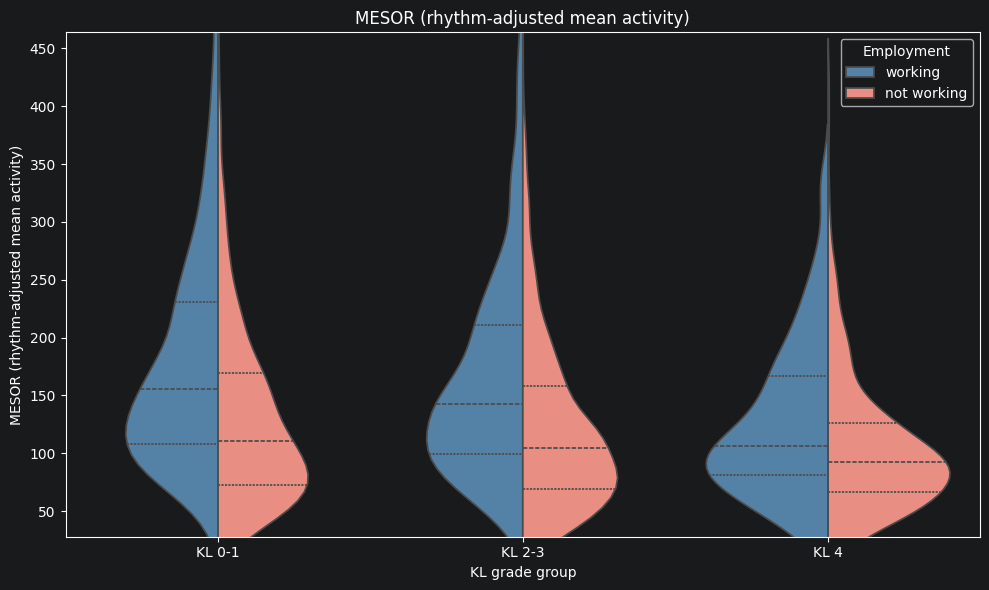

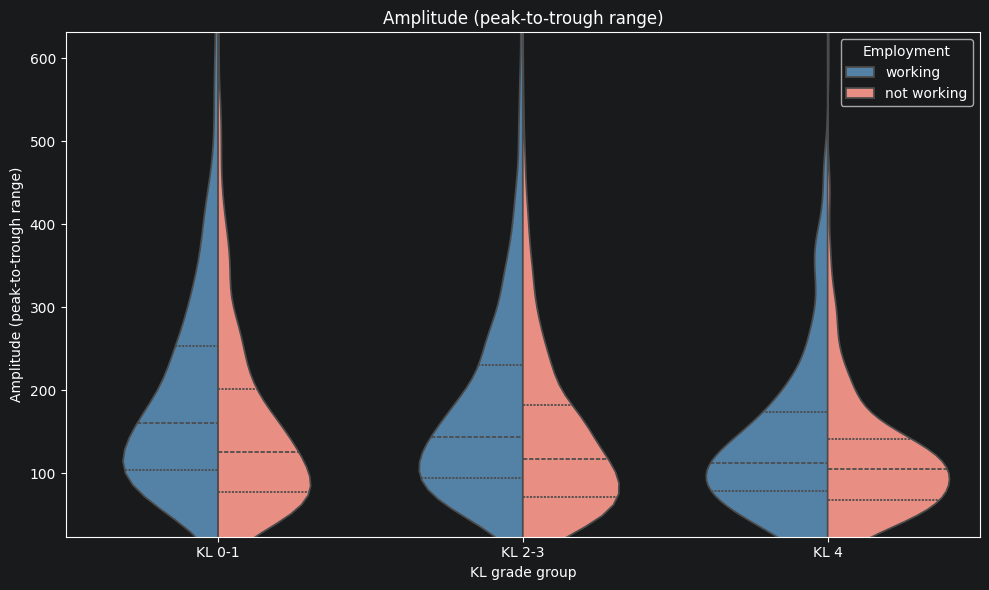

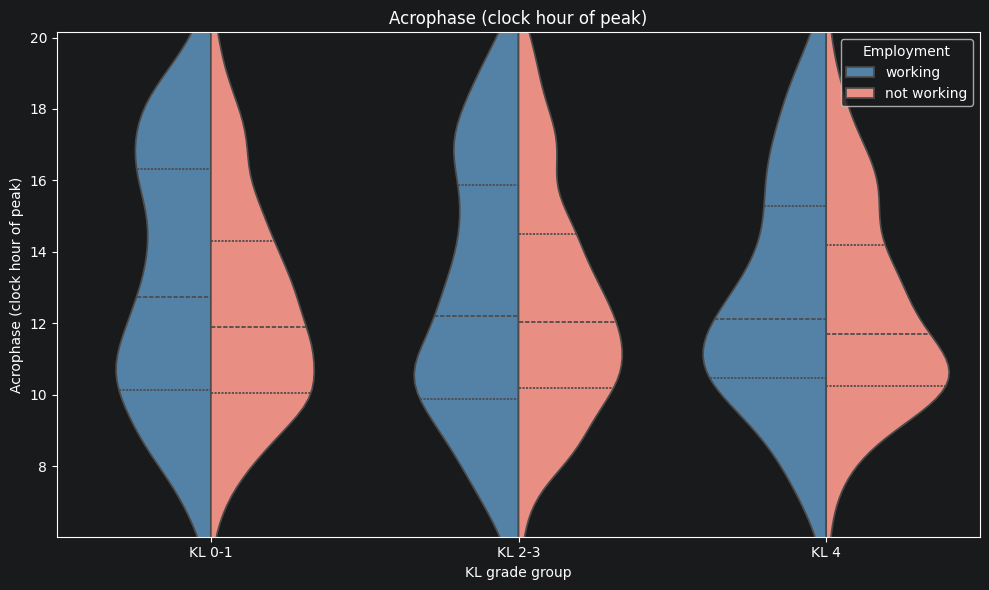

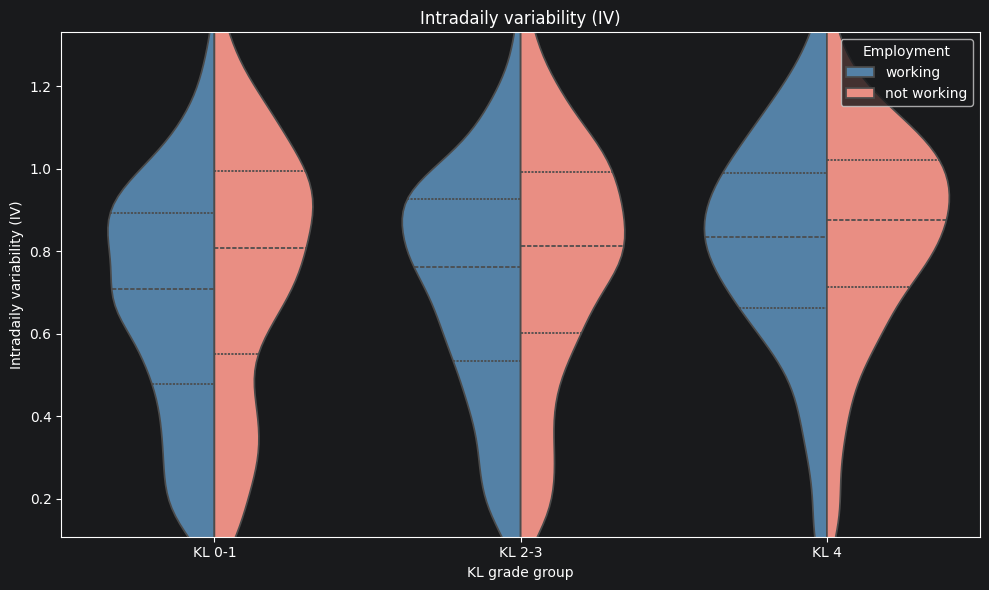

In [123]:
for feature in features_of_interest_daily:
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.violinplot(
        data=daily_metrics_06.dropna(subset=[feature]),
        x="kl_grade_group",
        y=feature,
        hue="employment_group",
        order=kl_order,
        hue_order=["working", "not working"],
        split=True,
        inner="quartile",
        palette={"working": "steelblue", "not working": "salmon"},
        ax=ax,
    )
    ax.set_xlabel("KL grade group")
    ax.set_ylabel(feature_labels[feature])
    ax.set_title(feature_labels[feature])
    ax.set_ylim(y_limits[feature])
    ax.legend(title="Employment", loc="upper right")

    plt.tight_layout()
    plt.show()

## 10.2 Interaction plots

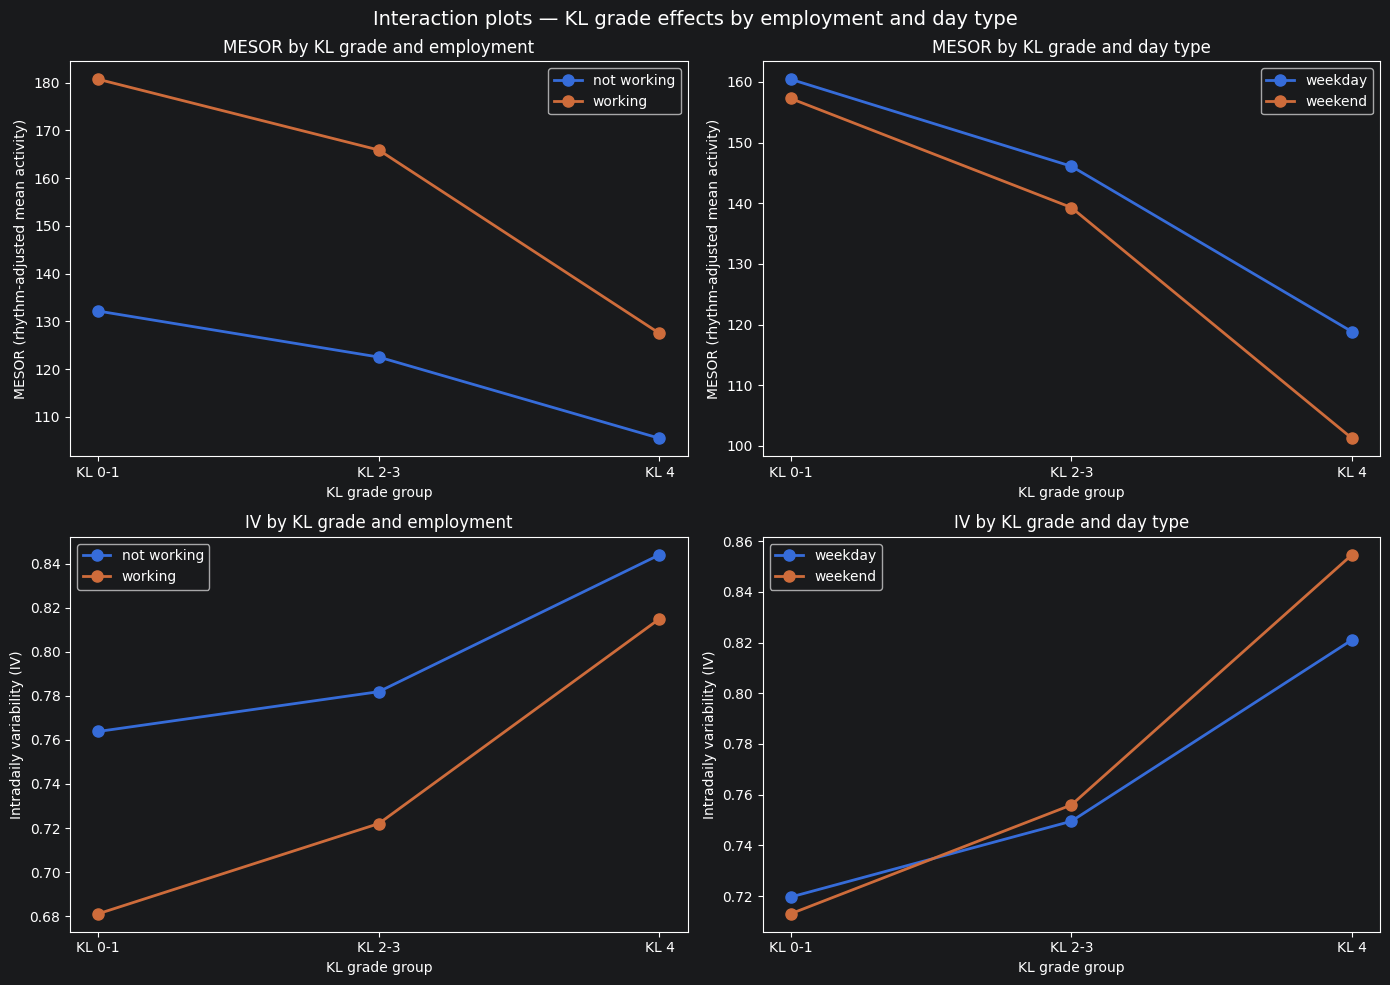

In [124]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

plot_specifications = [
    {"feature": "mesor_daily", "group": "employment_group", "title": "MESOR by KL grade and employment"},
    {"feature": "mesor_daily", "group": "day_type", "title": "MESOR by KL grade and day type"},
    {"feature": "intradaily_variability_daily", "group": "employment_group", "title": "IV by KL grade and employment"},
    {"feature": "intradaily_variability_daily", "group": "day_type", "title": "IV by KL grade and day type"},
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    plot_data = (
        daily_metrics_06
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

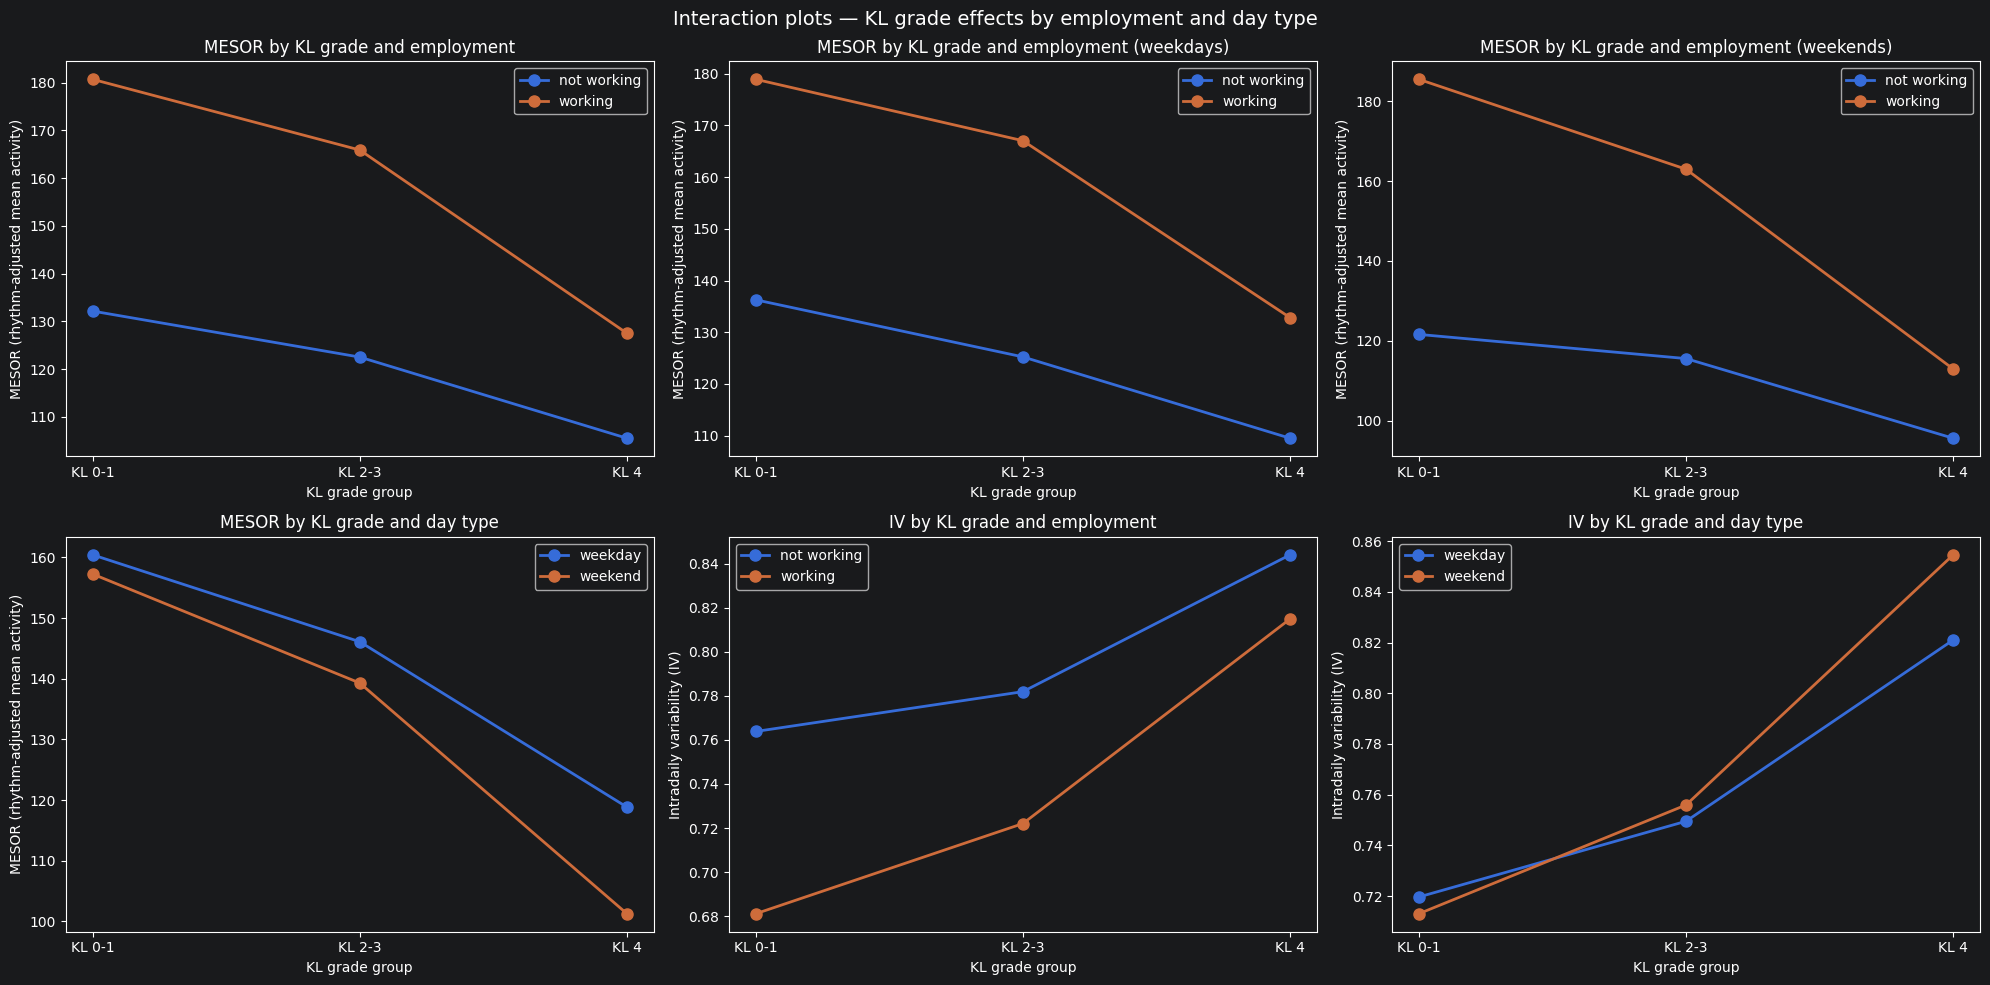

In [125]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

plot_specifications = [
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekdays)",
        "filter": {"column": "day_type", "value": "weekday"},
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekends)",
        "filter": {"column": "day_type", "value": "weekend"},
    },
    {
        "feature": "mesor_daily",
        "group": "day_type",
        "title": "MESOR by KL grade and day type",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "employment_group",
        "title": "IV by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "day_type",
        "title": "IV by KL grade and day type",
        "filter": None,
    },
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    data_subset = (
        daily_metrics_06[
            daily_metrics_06[specification["filter"]["column"]] == specification["filter"]["value"]
        ]
        if specification["filter"] is not None
        else daily_metrics_06
    )

    plot_data = (
        data_subset
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

## 10.3 Radar chart (rhythm profile by KL grade)

In [126]:
# Radar chart setup — aggregate per-day features by KL group and orient
# all axes so that "outer ring = healthier rhythm".

# Aggregate features per KL group (one mean per cell of a 3 x 4 table)
radar_data_for_chart = (
    daily_metrics_06
    .groupby("kl_grade_group")[list(feature_labels.keys())]
    .mean()
    .reindex(kl_order)
)

# Direction of "better" per feature.
# IV is inverted so that lower IV (less fragmentation) plots outward,
# matching the chart title's claim that higher = better.
# Acrophase is excluded because "later peak" is not directionally interpretable.
higher_is_better = {
    "mesor_daily": True,
    "amplitude_daily": True,
    "intradaily_variability_daily": False,
}

radar_data_for_chart = radar_data_for_chart[list(higher_is_better.keys())]

for feature, is_higher_better in higher_is_better.items():
    if not is_higher_better:
        radar_data_for_chart[feature] = -radar_data_for_chart[feature]

# Short axis labels for the corners of the polygon (must match column order)
categories = ["MESOR", "Amplitude", "IV (inverted)"]

# Angle for each axis around the circle, with a closing angle to wrap the polygon
number_of_features = len(categories)
angles = [
    n / number_of_features * 2 * np.pi
    for n in range(number_of_features)
]
angles += angles[:1]

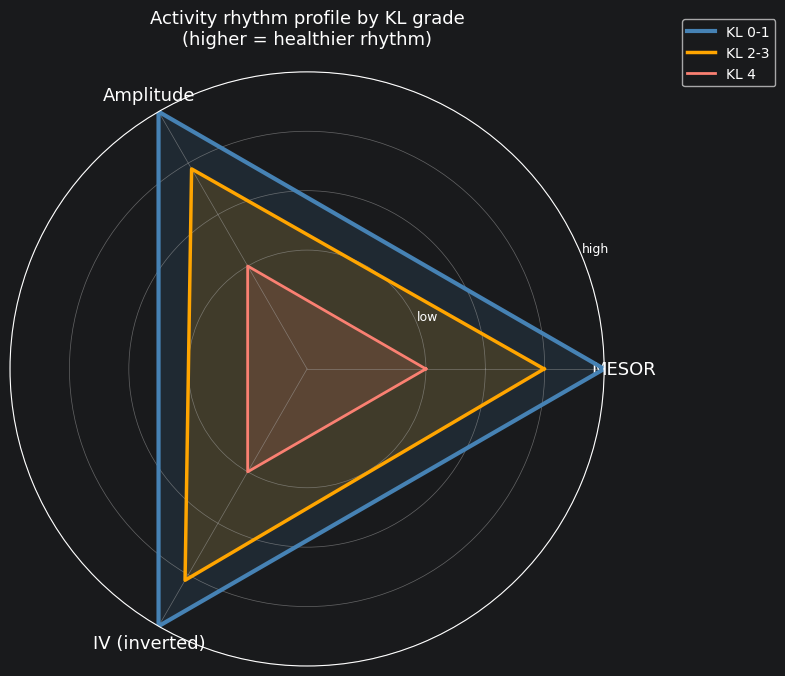

In [127]:
# Radar chart — activity rhythm profile by KL grade
# Each axis represents one feature, oriented so outer ring = healthier rhythm.
# Min-max scaled to a 0.4–1.0 band to amplify between-group differences
# while keeping all polygons visible inside the chart area.

radar_data_for_chart_scaled = (
    (radar_data_for_chart - radar_data_for_chart.min())
    / (radar_data_for_chart.max() - radar_data_for_chart.min())
) * 0.6 + 0.4

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

kl_group_colors = {
    "KL 0-1": "steelblue",
    "KL 2-3": "orange",
    "KL 4": "salmon",
}
kl_group_linewidths = {
    "KL 0-1": 3,
    "KL 2-3": 2.5,
    "KL 4": 2,
}

for kl_group in kl_order:
    values = radar_data_for_chart_scaled.loc[kl_group].tolist()
    values += values[:1]  # close the polygon

    ax.plot(
        angles,
        values,
        linewidth=kl_group_linewidths[kl_group],
        label=kl_group,
        color=kl_group_colors[kl_group],
    )
    ax.fill(
        angles,
        values,
        alpha=0.15,
        color=kl_group_colors[kl_group],
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13)
ax.set_ylim(0, 1)
ax.set_yticks([0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["low", "", "", "high"], fontsize=9)
ax.set_title(
    "Activity rhythm profile by KL grade\n(higher = healthier rhythm)",
    fontsize=13,
    pad=20,
)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

In [128]:
print(
    f"Participants:\n"
    f"  minute_metrics_06 : {minute_metrics_06['ID'].nunique():,}\n"
    f"  daily_metrics_06  : {daily_metrics_06['ID'].nunique():,}\n"
    f"  summary_metrics_06: {len(summary_metrics_06):,}"
)

Participants:
  minute_metrics_06 : 1,357
  daily_metrics_06  : 1,357
  summary_metrics_06: 1,357
